# Lección 1.2 · Genes, genomas y marcos abiertos de lectura (ORF finder)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-01-biologia-molecular/1.2_genes_orfs.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 1 — Biología molecular para bioinformáticos** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio | Lecciones 0.1–0.3 (Python, numpy, Biopython) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** la anatomía de un gen procariota y de uno eucariota, y reconocer las señales que la célula usa para
   encontrar dónde empieza y dónde termina un gen.
2. **Definir** con precisión qué es un marco abierto de lectura (ORF) y **programar** un buscador de ORFs en los seis
   marcos de lectura.
3. **Deducir** el modelo nulo geométrico de la longitud de los ORFs y usarlo para decidir cuándo un ORF es
   "demasiado largo para ser casualidad".
4. **Descubrir**, con datos reales de *Mycoplasma genitalium*, por qué elegir el código genético correcto cambia
   por completo la anotación de un genoma.
5. **Evaluar** un predictor de genes con sensibilidad y precisión, e **identificar** la trampa de los "ORFs sombra".

## 🗺️ Mapa de la clase

1. ¿Qué es un gen? Las señales de "empiece" y "termine"
2. Marcos de lectura: un ejemplo resuelto a mano
3. El algoritmo: un buscador de ORFs paso a paso (con animación)
4. El modelo nulo: ¿cuán largo puede ser un ORF por puro azar?
5. 🧪 Un genoma real: *Mycoplasma genitalium* y su código genético peculiar
6. 🧪 Señal contra ruido: ORFs reales contra un genoma barajado
7. 🧪 Evaluación del predictor: sensibilidad, precisión y ORFs sombra
8. 🧭 Un navegador genómico interactivo
9. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
import plotly.express as px
import plotly.graph_objects as go
from Bio import SeqIO, Entrez
from Bio.Seq import Seq
from Bio.Data import CodonTable
print("Biopython", Bio.__version__)

Entorno listo ✔  |  Colab: False
Biopython 1.88


## 1. ¿Qué es un gen? Las señales de "empiece" y "termine"

Imagine un libro de cocina de 580 000 letras escrito **sin espacios, sin puntos y sin títulos**: sólo las letras
`A`, `C`, `G` y `T`, una detrás de otra. En algún lugar de ese texto están escritas unas 500 recetas (los genes),
pero nadie las subrayó. La célula, sin embargo, las encuentra sin equivocarse. ¿Cómo? Porque cada receta está
rodeada de **señales** que la maquinaria molecular sabe leer:

* Una señal que dice **"aquí se empieza a copiar"** (el **promotor**, donde se pega la ARN polimerasa).
* Una señal que dice **"aquí se sienta el ribosoma"** (en bacterias, la secuencia de **Shine-Dalgarno**, parecida a
  `AGGAGG`, unas 8 bases antes del inicio).
* Una palabra de **inicio de la traducción**: casi siempre el codón `ATG` (a veces `GTG` o `TTG` en bacterias).
* Una palabra de **fin**: uno de los **codones de parada** `TAA`, `TAG` o `TGA`.
* Una señal de **"deje de copiar"** (el **terminador** de la transcripción).

Un **gen codificante** es, entonces, el tramo de ADN que la célula transcribe a ARN y cuyo núcleo —la **secuencia
codificante** o **CDS**— el ribosoma traduce a proteína, tres letras a la vez, desde el codón de inicio hasta el
primer codón de parada **en el mismo marco de lectura**.

### Procariotas y eucariotas: dos formatos de receta

En las **bacterias** la receta es continua: la CDS no tiene interrupciones. En los **eucariotas** (hongos, plantas,
animales) la receta viene "intercalada con publicidad": los **exones** (lo que sí se usa) están separados por
**intrones** (lo que se recorta). Después de copiar el gen a ARN, la célula **corta los intrones y empalma los
exones** (*splicing*), añade una **caperuza** en el extremo 5' y una **cola de poli-A** en el 3'.

Esto tiene una consecuencia práctica enorme para nosotros: **en bacterias, buscar genes es casi buscar tramos largos
sin codones de parada**; en eucariotas no basta, porque los intrones rompen el marco de lectura. Por eso esta lección
trabaja con una bacteria.

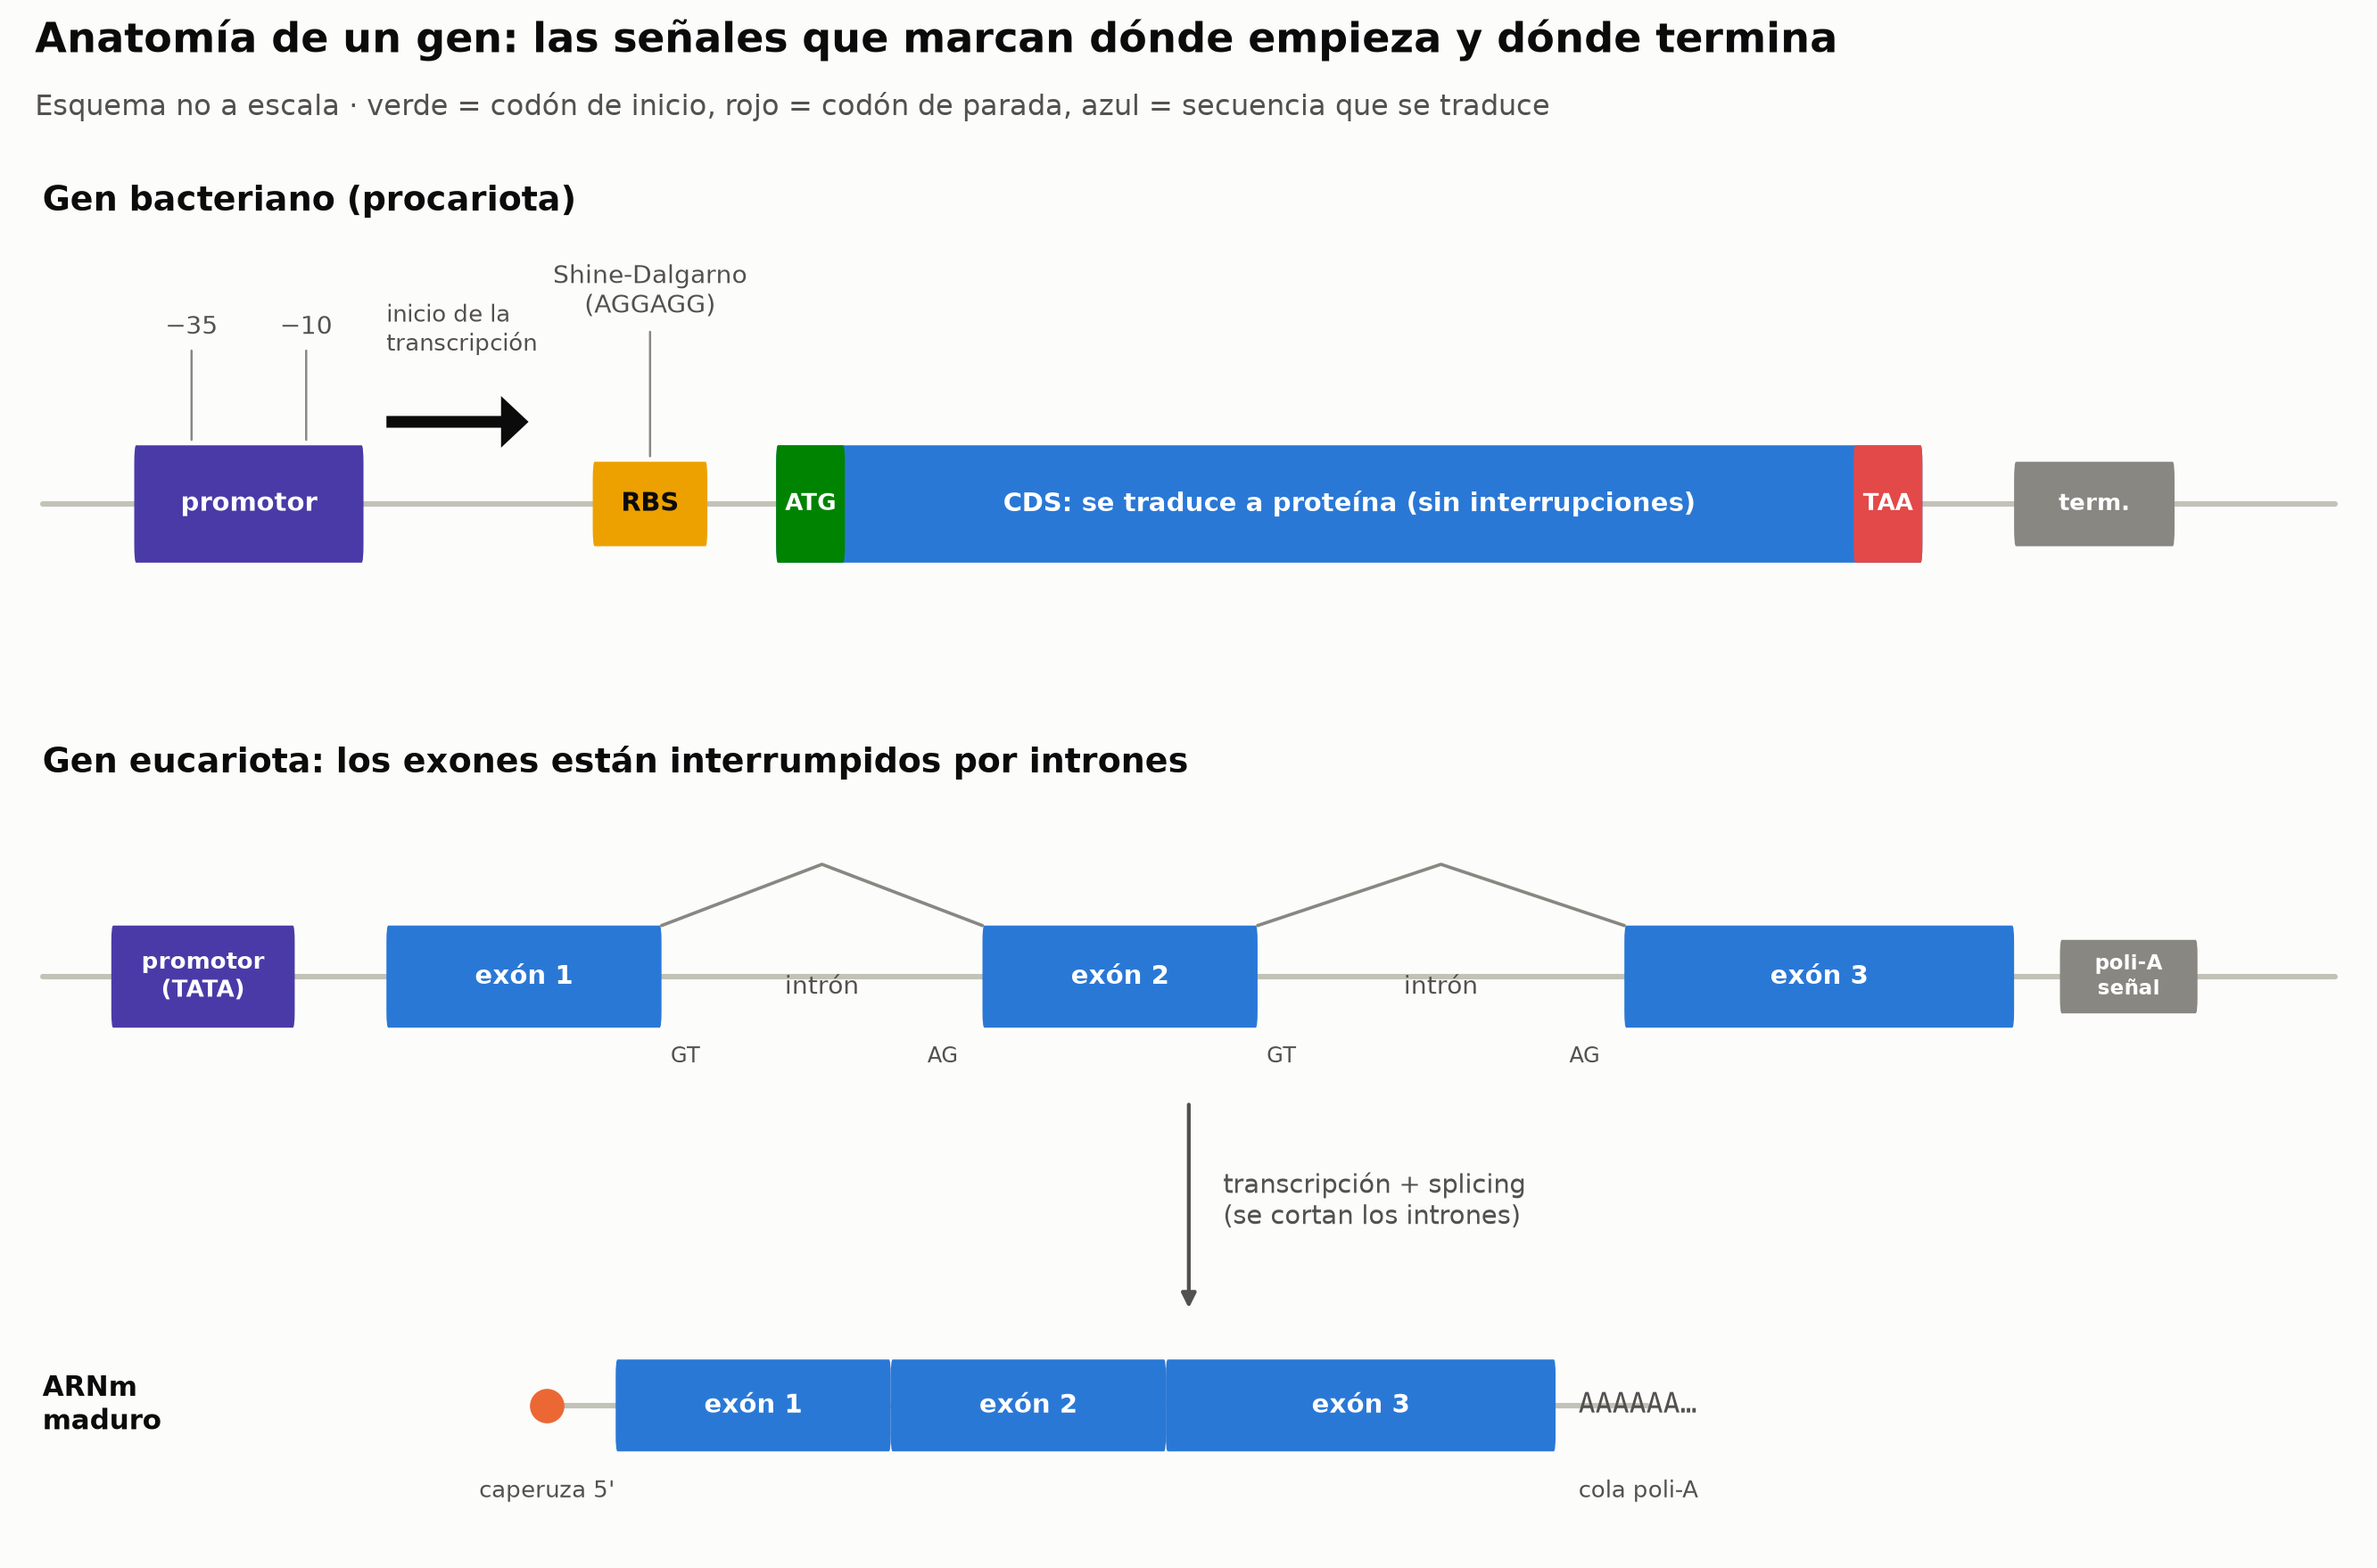

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrow

def box(ax, x0, x1, y, h, color, label=None, text_color="white", fs=9.5, weight="bold"):
    ax.add_patch(FancyBboxPatch((x0, y - h / 2), x1 - x0, h, boxstyle="round,pad=0,rounding_size=0.08",
                                color=color, lw=0))
    if label:
        ax.text((x0 + x1) / 2, y, label, ha="center", va="center", color=text_color, fontsize=fs, fontweight=weight)

def note(ax, x, y, text, dy=0.55, ha="center"):
    ax.annotate(text, xy=(x, y), xytext=(x, y + dy), ha=ha, va="bottom", fontsize=9, color=ec.INK_2,
                arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.2), height_ratios=[1, 1.45])

# --- Gen procariota ---
ax1.plot([0, 100], [0, 0], color=ec.BASELINE, lw=2, zorder=0)
box(ax1, 4, 14, 0, 0.5, ec.VIOLET, "promotor")
note(ax1, 6.5, 0.25, "−35", dy=0.45); note(ax1, 11.5, 0.25, "−10", dy=0.45)
ax1.add_patch(FancyArrow(15, 0.35, 5, 0, width=0.05, head_width=0.22, head_length=1.2, color=ec.INK, lw=0))
ax1.text(15, 0.62, "inicio de la\ntranscripción", fontsize=8.5, color=ec.INK_2, va="bottom")
box(ax1, 24, 29, 0, 0.36, ec.YELLOW, "RBS", text_color=ec.INK)
note(ax1, 26.5, 0.18, "Shine-Dalgarno\n(AGGAGG)", dy=0.6)
box(ax1, 32, 82, 0, 0.5, ec.BLUE, "CDS: se traduce a proteína (sin interrupciones)")
box(ax1, 32, 35, 0, 0.5, ec.GREEN, "ATG", fs=8.5)
box(ax1, 79, 82, 0, 0.5, ec.RED, "TAA", fs=8.5)
box(ax1, 86, 93, 0, 0.36, ec.MUTED, "term.", fs=8.5)
ax1.text(0, 1.25, "Gen bacteriano (procariota)", fontsize=12.5, fontweight="bold", color=ec.INK)
ax1.set_xlim(-1, 101); ax1.set_ylim(-0.9, 1.5); ax1.axis("off")

# --- Gen eucariota y su ARNm maduro ---
y_dna, y_mrna = 1.2, -0.9
ax2.plot([0, 100], [y_dna, y_dna], color=ec.BASELINE, lw=2, zorder=0)
box(ax2, 3, 11, y_dna, 0.5, ec.VIOLET, "promotor\n(TATA)", fs=8.5)
exons = [(15, 27, "exón 1"), (41, 53, "exón 2"), (69, 86, "exón 3")]
introns = [(27, 41), (53, 69)]
for x0, x1, lab in exons:
    box(ax2, x0, x1, y_dna, 0.5, ec.BLUE, lab)
for x0, x1 in introns:
    ax2.plot([x0, (x0 + x1) / 2, x1], [y_dna + 0.25, y_dna + 0.55, y_dna + 0.25], color=ec.MUTED, lw=1.2)
    ax2.text((x0 + x1) / 2, y_dna - 0.05, "intrón", ha="center", va="center", fontsize=9, color=ec.INK_2)
    ax2.text(x0 + 0.4, y_dna - 0.42, "GT", fontsize=8, color=ec.INK_2); ax2.text(x1 - 2.4, y_dna - 0.42, "AG", fontsize=8, color=ec.INK_2)
box(ax2, 88, 94, y_dna, 0.36, ec.MUTED, "poli-A\nseñal", fs=7.5)
ax2.text(0, y_dna + 1.0, "Gen eucariota: los exones están interrumpidos por intrones", fontsize=12.5,
         fontweight="bold", color=ec.INK)
# splicing
ax2.annotate("", xy=(50, y_mrna + 0.45), xytext=(50, y_dna - 0.6),
             arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.4))
ax2.text(51.5, (y_mrna + y_dna) / 2 - 0.05, "transcripción + splicing\n(se cortan los intrones)", fontsize=9.5,
         color=ec.INK_2, va="center")
ax2.plot([22, 70], [y_mrna, y_mrna], color=ec.BASELINE, lw=2, zorder=0)
ax2.scatter([22], [y_mrna], s=160, color=ec.ORANGE, zorder=3)
ax2.text(22, y_mrna - 0.45, "caperuza 5'", ha="center", fontsize=8.5, color=ec.INK_2)
x = 25
for x0, x1, lab in exons:
    w = x1 - x0
    box(ax2, x, x + w, y_mrna, 0.45, ec.BLUE, lab); x += w
ax2.text(x + 1, y_mrna, "AAAAAA…", va="center", fontsize=10, color=ec.INK_2, family="DejaVu Sans Mono")
ax2.text(x + 1, y_mrna - 0.45, "cola poli-A", fontsize=8.5, color=ec.INK_2)
ax2.text(0, y_mrna, "ARNm\nmaduro", fontsize=10, color=ec.INK, va="center", fontweight="bold")
ax2.set_xlim(-1, 101); ax2.set_ylim(-1.6, 2.4); ax2.axis("off")
ec.fig_title(fig, "Anatomía de un gen: las señales que marcan dónde empieza y dónde termina",
             "Esquema no a escala · verde = codón de inicio, rojo = codón de parada, azul = secuencia que se traduce")
plt.show()

> 🔎 **Qué observamos.** En la bacteria, la parte que se traduce (azul) es **un único bloque** entre un `ATG` y un
> codón de parada. En el eucariota, la proteína está "repartida" en exones; sólo después del *splicing* queda un
> bloque continuo. Por eso los buscadores de genes eucariotas (como AUGUSTUS) necesitan modelos mucho más complejos
> que el que construiremos hoy.

✅ **Compruebe su comprensión.** Si usted tomara el ADN genómico humano de un gen con 3 intrones y lo tradujera
directamente de principio a fin, ¿obtendría la proteína correcta? ¿Qué pasaría al llegar al primer intrón?

---

## 2. Marcos de lectura: un ejemplo resuelto a mano

Los codones se leen de tres en tres **sin comas y sin solaparse**. Por eso, una misma secuencia puede "cortarse" en
codones de tres maneras distintas en cada hebra, según en qué letra empecemos. Es como leer la cadena
`ELSOLSALEYELGATOSEVA`: si empezamos en la primera letra y cortamos de a tres obtenemos `ELS OLS ALE YEL…`; si
empezamos en la segunda, `LSO LSA LEY ELG…`. Sólo **una** forma de cortar tiene sentido.

Tomemos la secuencia de 29 nucleótidos:

```
5'-CATGAAACCCTAAGATGTTTGGGTGACAT-3'
```

**Marco +1** (empezamos en la letra 1): `CAT GAA ACC CTA AGA TGT TTG GGT GAC AT` → no aparece `ATG` ni parada.

**Marco +2** (empezamos en la letra 2): `ATG AAA CCC TAA GAT GTT TGG GTG ACA T` → ¡`ATG` en la posición 2 y `TAA` tres
codones después! Ese es un **marco abierto de lectura (ORF)** que codifica `M K P` y se detiene.

**Marco +3** (empezamos en la letra 3): `TGA AAC CCT AAG ATG TTT GGG TGA CAT` → hay un `ATG` en el codón 5 y un `TGA`
en el codón 8: otro ORF, `M F G`.

Y faltan los tres marcos de la **hebra complementaria** (−1, −2, −3), que se leen sobre el complemento reverso.
Veámoslo en una figura:

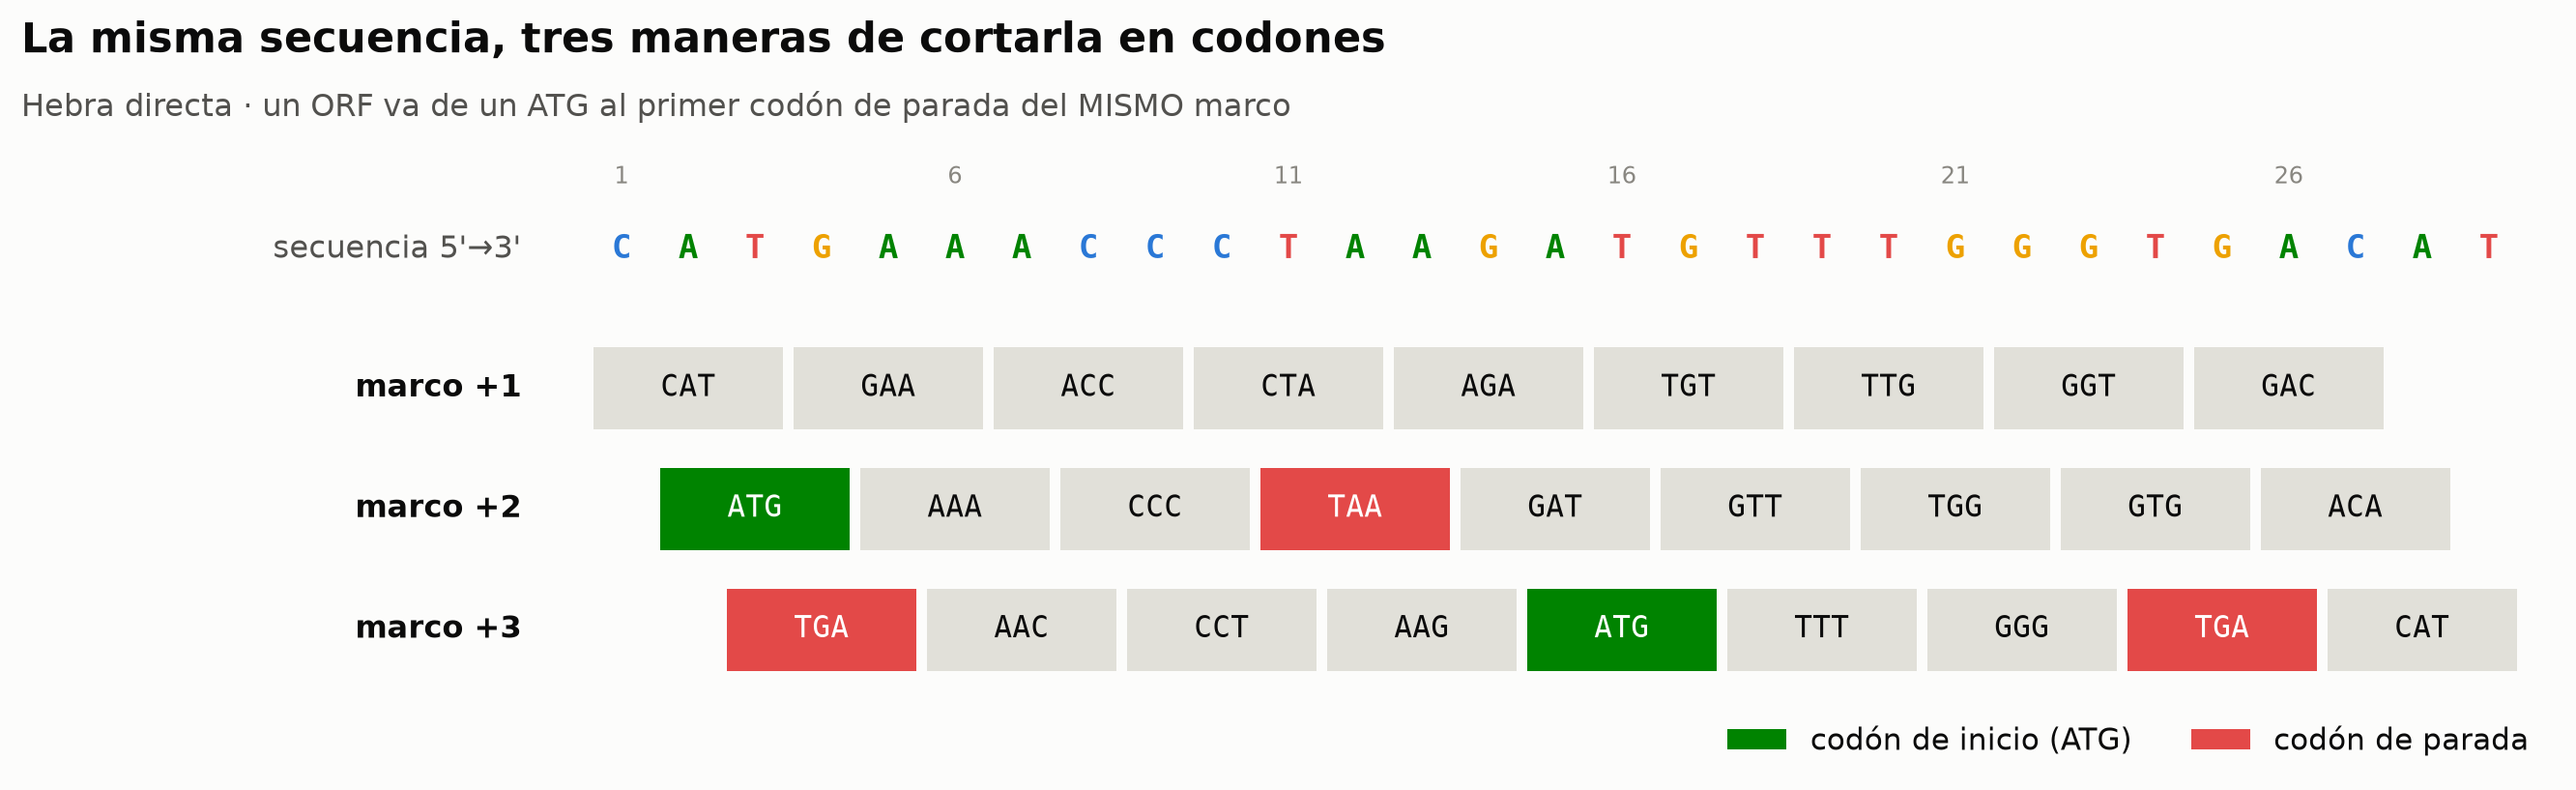

In [3]:
STARTS = {"ATG"}
STOPS = {"TAA", "TAG", "TGA"}
demo = "CATGAAACCCTAAGATGTTTGGGTGACAT"

def draw_frames(ax, seq, frames=(0, 1, 2), y0=0, label_prefix="+"):
    """Dibuja los codones de cada marco como cajas coloreadas (inicio verde, parada roja)."""
    for row, f in enumerate(frames):
        y = y0 - row
        ax.text(-1.0, y, f"marco {label_prefix}{f + 1}", ha="right", va="center", fontsize=10.5,
                color=ec.INK, fontweight="bold")
        for k in range((len(seq) - f) // 3):
            codon = seq[f + 3 * k: f + 3 * k + 3]
            color = ec.GREEN if codon in STARTS else ec.RED if codon in STOPS else ec.GRID
            ax.add_patch(plt.Rectangle((f + 3 * k + 0.08, y - 0.34), 2.84, 0.68, color=color, lw=0))
            ax.text(f + 3 * k + 1.5, y, codon, ha="center", va="center", fontsize=10,
                    family="DejaVu Sans Mono", color="white" if color != ec.GRID else ec.INK)

fig, ax = plt.subplots(figsize=(12, 3.6))
for i, b in enumerate(demo):     # la secuencia original como regla de nucleótidos
    ax.text(i + 0.5, 1.15, b, ha="center", va="center", fontsize=11, family="DejaVu Sans Mono",
            color=ec.NUC_COLORS[b], fontweight="bold")
    if i % 5 == 0:
        ax.text(i + 0.5, 1.7, str(i + 1), ha="center", fontsize=8, color=ec.MUTED)
ax.text(-1.0, 1.15, "secuencia 5'→3'", ha="right", va="center", fontsize=10.5, color=ec.INK_2)
draw_frames(ax, demo)
ax.set_xlim(-8.5, len(demo) + 0.5); ax.set_ylim(-2.7, 2.1); ax.axis("off")
ax.add_patch(plt.Rectangle((0, 0), 0, 0, color=ec.GREEN, label="codón de inicio (ATG)"))
ax.add_patch(plt.Rectangle((0, 0), 0, 0, color=ec.RED, label="codón de parada"))
ax.legend(loc="lower right", ncol=2, bbox_to_anchor=(1, -0.12))
ec.title(ax, "La misma secuencia, tres maneras de cortarla en codones",
         "Hebra directa · un ORF va de un ATG al primer codón de parada del MISMO marco")
plt.show()

> 🔎 **Qué observamos.** Un `ATG` sólo "abre" un ORF en su propio marco. El `TAA` del marco +2 no cierra el ORF del
> marco +3, aunque estén uno al lado del otro. Cada marco es una lectura independiente.

✅ **Compruebe su comprensión.** Escriba el complemento reverso de `demo` y busque a mano los ORFs de los marcos −1,
−2 y −3. Luego compruébelo con `str(Seq(demo).reverse_complement())`.

---

## 3. El algoritmo: un buscador de ORFs paso a paso

Formalicemos lo que hicimos a mano. Para **cada una de las 6 lecturas** (3 marcos × 2 hebras):

1. Cortar la secuencia en codones.
2. Recorrer los codones de izquierda a derecha. Cuando encontramos un **codón de inicio** y **no** estamos dentro de
   un ORF, marcamos "aquí empieza un ORF".
3. Cuando encontramos un **codón de parada** y estamos dentro de un ORF, lo cerramos y lo guardamos (con su longitud).
4. Al final, conservamos sólo los ORFs con al menos $\ell_{\min}$ codones.

Tomar el **primer** inicio después de la parada anterior produce el ORF **más largo posible** (el verdadero inicio del
gen puede estar un poco más adentro; lo resolveremos al evaluar). Primero, una versión clara y legible:

In [4]:
def find_orfs_simple(seq: str, min_codons: int = 1, starts=STARTS, stops=STOPS):
    """Versión didáctica: recorre los 6 marcos codón por codón."""
    seq = seq.upper()
    L = len(seq)
    rc = str(Seq(seq).reverse_complement())
    orfs = []
    for strand, s in [(+1, seq), (-1, rc)]:
        for frame in range(3):
            start = None
            for k in range(frame, len(s) - 2, 3):
                codon = s[k:k + 3]
                if start is None and codon in starts:
                    start = k                              # se abre un ORF
                elif start is not None and codon in stops:
                    n_codons = (k - start) // 3            # codones traducidos (sin contar la parada)
                    if n_codons >= min_codons:
                        a, b = start, k + 3                # coordenadas 0-based, semiabiertas [a, b)
                        if strand == -1:                   # convertir a coordenadas de la hebra directa
                            a, b = L - b, L - a
                        orfs.append({"start": a, "end": b, "strand": strand, "frame": frame + 1,
                                     "codons": n_codons})
                    start = None                           # se cierra el ORF
    return pd.DataFrame(orfs)

find_orfs_simple(demo)

,start,end,strand,frame,codons
0,1,13,1,2,3
1,14,26,1,3,3


Recorrer un genoma codón por codón en Python puro es lento (lo vimos en la Lección 0.1). La versión rápida hace lo
mismo con `numpy`: convierte cada codón en un número del 0 al 63, marca todas las paradas y todos los inicios de una
sola vez, y para cada parada busca **el primer inicio posterior a la parada anterior** con `np.searchsorted`
(búsqueda binaria).

In [5]:
BASE_IDX = np.full(256, -1, dtype=np.int64)
for i, b in enumerate("TCAG"):
    BASE_IDX[ord(b)] = i
COMPLEMENT = str.maketrans("ACGTN", "TGCAN")

def codon_id(c: str) -> int:
    return 16 * "TCAG".index(c[0]) + 4 * "TCAG".index(c[1]) + "TCAG".index(c[2])

def codon_ids(s: str) -> np.ndarray:
    """Cada codón → número 0..63 (−1 si contiene una base ambigua)."""
    a = BASE_IDX[np.frombuffer(s.encode("ascii"), dtype=np.uint8)]
    n = len(a) // 3
    a = a[: 3 * n].reshape(n, 3)
    ids = 16 * a[:, 0] + 4 * a[:, 1] + a[:, 2]
    ids[(a < 0).any(axis=1)] = -1
    return ids

def find_orfs(seq: str, min_codons: int = 100, starts=("ATG",), stops=("TAA", "TAG", "TGA")) -> pd.DataFrame:
    """Buscador de ORFs vectorizado en los 6 marcos. Devuelve coordenadas 0-based [start, end) en la hebra +."""
    seq = seq.upper()
    L = len(seq)
    rc = seq.translate(COMPLEMENT)[::-1]
    stop_ids, start_ids = [codon_id(c) for c in stops], [codon_id(c) for c in starts]
    rows = []
    for strand, s in [(+1, seq), (-1, rc)]:
        for frame in range(3):
            c = codon_ids(s[frame:])
            stop_pos = np.flatnonzero(np.isin(c, stop_ids))
            start_pos = np.flatnonzero(np.isin(c, start_ids))
            prev_stop = np.concatenate([[-1], stop_pos[:-1]])
            k = np.searchsorted(start_pos, prev_stop + 1)          # primer inicio tras la parada anterior
            has = k < len(start_pos)
            first_start = np.full(len(stop_pos), np.iinfo(np.int64).max)
            first_start[has] = start_pos[k[has]]
            n_codons = stop_pos - first_start
            keep = (first_start < stop_pos) & (n_codons >= min_codons)
            a = frame + 3 * first_start[keep]
            b = frame + 3 * stop_pos[keep] + 3
            if strand == -1:
                a, b = L - b, L - a
            rows.append(pd.DataFrame({"start": a, "end": b, "strand": strand, "frame": frame + 1,
                                      "codons": n_codons[keep]}))
    return pd.concat(rows, ignore_index=True).sort_values("start", ignore_index=True)

# Control de calidad: ambas versiones deben coincidir en una secuencia aleatoria
rng = np.random.default_rng(1)
test_seq = "".join(rng.choice(list("ACGT"), 20_000))
simple = find_orfs_simple(test_seq, min_codons=20).sort_values(["start", "end"]).reset_index(drop=True)
fast = find_orfs(test_seq, min_codons=20).sort_values(["start", "end"]).reset_index(drop=True)
print("ORFs (versión simple):", len(simple), "| ORFs (versión numpy):", len(fast))
print("¿Idénticos?", simple[["start", "end", "strand"]].equals(fast[["start", "end", "strand"]]))

ORFs (versión simple): 189 | ORFs (versión numpy): 189
¿Idénticos? True


### 🎬 El buscador en acción

La animación muestra el algoritmo recorriendo los seis marcos de una secuencia de 90 nucleótidos. Las filas de la
hebra complementaria se muestran ya invertidas y complementadas, de modo que **todas se leen de izquierda a derecha
(5'→3')**. Observe cómo un ORF queda "abierto" (azul claro) al ver un `ATG` y se "cierra" (azul intenso) al llegar a
una parada del mismo marco.

![El buscador de ORFs recorre los seis marcos de lectura](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-01-biologia-molecular/1.2_escaner_orfs.gif)

*El buscador de ORFs recorre los seis marcos de lectura*

In [6]:
anim_seq = "GCATGGCTAAAGAACTGTTTGCATAAGGATGCGTCATGACCTGAAATTCAGCAAGCTTTTACGCATGGTTATCTTAAGCTATCATGCTGA"
anim_rc = str(Seq(anim_seq).reverse_complement())
rows = [(anim_seq, f, f"+{f + 1}") for f in range(3)] + [(anim_rc, f, f"−{f + 1}") for f in range(3)]
n_steps = len(anim_seq) // 3

fig, ax = plt.subplots(figsize=(12.5, 4.6))
cells = []          # (fila, índice de codón, rectángulo, texto, codón)
for r, (s, f, lab) in enumerate(rows):
    y = -r - (0.5 if r >= 3 else 0)                       # espacio entre hebras
    ax.text(-1.2, y, f"marco {lab}", ha="right", va="center", fontsize=10, color=ec.INK, fontweight="bold")
    for k in range((len(s) - f) // 3):
        codon = s[f + 3 * k: f + 3 * k + 3]
        rect = plt.Rectangle((f + 3 * k + 0.1, y - 0.36), 2.8, 0.72, color=ec.SURFACE, ec=ec.GRID, lw=0.8)
        ax.add_patch(rect)
        txt = ax.text(f + 3 * k + 1.5, y, codon, ha="center", va="center", fontsize=8,
                      family="DejaVu Sans Mono", color=ec.MUTED)
        cells.append((r, k, rect, txt, codon))
ax.text(-1.2, 0.95, "hebra +", ha="right", fontsize=9.5, color=ec.INK_2)
ax.text(-1.2, -2.55, "hebra − (5'→3')", ha="right", fontsize=9.5, color=ec.INK_2)
scanner = ax.axvline(0, color=ec.ORANGE, lw=2.5)
counter = ax.text(len(anim_seq), 1.0, "", ha="right", fontsize=10, color=ec.INK_2)
ax.set_xlim(-9, len(anim_seq) + 1); ax.set_ylim(-6.1, 1.4); ax.axis("off")
ax.set_title("Un buscador de ORFs recorre los 6 marcos de lectura", loc="left")

def row_state(r, upto):
    """Estado de cada codón de la fila r tras leer 'upto' nucleótidos."""
    state, open_start = {}, None
    for (rr, k, _, _, codon) in cells:
        if rr != r or 3 * k + rows[r][1] + 3 > upto:
            continue
        if open_start is None and codon in STARTS:
            open_start = k; state[k] = "start"
        elif open_start is not None and codon in STOPS:
            for j in range(open_start + 1, k):
                state[j] = "orf"
            state[k] = "stop"; open_start = None
        else:
            state[k] = "open" if open_start is not None else "seen"
    return state

colors = {"seen": ec.GRID, "open": ec.SEQ_BLUE[0], "orf": ec.SEQ_BLUE[5], "start": ec.GREEN, "stop": ec.RED}
frames_idx = list(range(1, n_steps + 1)) + [n_steps] * 8

def update(i):
    upto = 3 * frames_idx[i] + 2
    states = [row_state(r, upto) for r in range(6)]
    for (r, k, rect, txt, codon) in cells:
        st = states[r].get(k)
        if st is None:
            rect.set_facecolor(ec.SURFACE); txt.set_color(ec.MUTED)
        else:
            rect.set_facecolor(colors[st])
            txt.set_color("white" if st in ("orf", "start", "stop") else ec.INK)
    scanner.set_xdata([upto, upto])
    counter.set_text(f"posición {min(upto, len(anim_seq))} / {len(anim_seq)} nt")
    return ()

ec.animate(fig, update, frames=len(frames_idx), interval=220, name="1.2_escaner_orfs")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

---

## 4. El modelo nulo: ¿cuán largo puede ser un ORF por puro azar?

Aquí está el corazón estadístico de la lección. Si escribimos letras al azar, **también aparecen ORFs**, sólo que
cortos: tarde o temprano "tropezamos" con un codón de parada. La pregunta útil es: **¿qué longitud es tan improbable
por azar que casi seguro se trata de un gen real?**

### Un cálculo a mano

En una secuencia donde las cuatro bases aparecen con la misma frecuencia, hay $4^3 = 64$ codones posibles, de los
cuales 3 son de parada. Entonces, al leer un codón cualquiera:

$$
P(\text{parada}) = \frac{3}{64} \approx 0.047 \qquad\qquad P(\text{no parada}) = \frac{61}{64} \approx 0.953
$$

¿Cuál es la probabilidad de leer **100 codones seguidos sin tropezar con una parada**? Como cada codón es
independiente, multiplicamos (igual que la probabilidad de sacar 100 caras seguidas con una moneda cargada):

$$
P(\text{100 codones sin parada}) = \left(\frac{61}{64}\right)^{100} = e^{100 \,\ln(61/64)} \approx e^{-4.80} \approx 0.0082
$$

Menos del 1 %. Y para 300 codones (una proteína típica): $(61/64)^{300} \approx 5.5 \times 10^{-7}$. **Los genes
reales son larguísimos comparados con lo que produce el azar.**

### La distribución geométrica

Sea $L$ el número de codones que leemos **antes** de la primera parada. Lo anterior se generaliza así:

$$
\boxed{\;P(L \ge \ell) = (1 - p)^{\ell}\;}
\qquad\qquad
\mathbb{E}[L] = \frac{1 - p}{p}
$$

| Símbolo | Significado |
|---|---|
| $\ell$ | una longitud en codones (el umbral que nos interesa) |
| $L$ | longitud (en codones) de un tramo sin paradas: una variable aleatoria |
| $p$ | probabilidad de que un codón al azar sea de parada ($3/64$ con bases equiprobables) |
| $P(L \ge \ell)$ | **función de supervivencia**: fracción de tramos que "sobreviven" al menos $\ell$ codones |
| $\mathbb{E}[L]$ | longitud media esperada: con $p = 3/64$, $\;61/3 \approx 20.3$ codones |

Al tomar logaritmos, $\log P(L \ge \ell) = \ell \cdot \log(1-p)$: **en escala logarítmica la supervivencia es una
recta** con pendiente $\log(1-p)$. Esa es la firma visual del azar, y la usaremos enseguida.

### ¿Y si las bases no son equiprobables?

*M. genitalium* tiene sólo ~32 % de GC, así que la `A` y la `T` abundan… y los codones de parada (`TAA`, `TAG`,
`TGA`) están hechos justamente de `A` y `T`. La probabilidad de parada depende de la composición:

$$
p \;=\; \sum_{c \,\in\, \text{paradas}} \; p_{c_1}\, p_{c_2}\, p_{c_3}
$$

donde $p_{c_i}$ es la frecuencia de la base en la posición $i$ del codón $c$. Por ejemplo, con
$p_A = p_T = 0.34$ y $p_G = p_C = 0.16$: $\;p(\texttt{TAA}) = 0.34^3 \approx 0.039$,
$\;p(\texttt{TAG}) = p(\texttt{TGA}) = 0.34^2 \cdot 0.16 \approx 0.018$. En genomas ricos en AT los ORFs por azar
son **aún más cortos**; en genomas ricos en GC, más largos (lo verá en el Ejercicio 1).

🤔 **Antes de ejecutar, prediga:** si simulamos 1 millón de bases al azar y graficamos la supervivencia en escala
log, ¿qué forma tendrá la curva? ¿Dónde cruzará el 1 %?

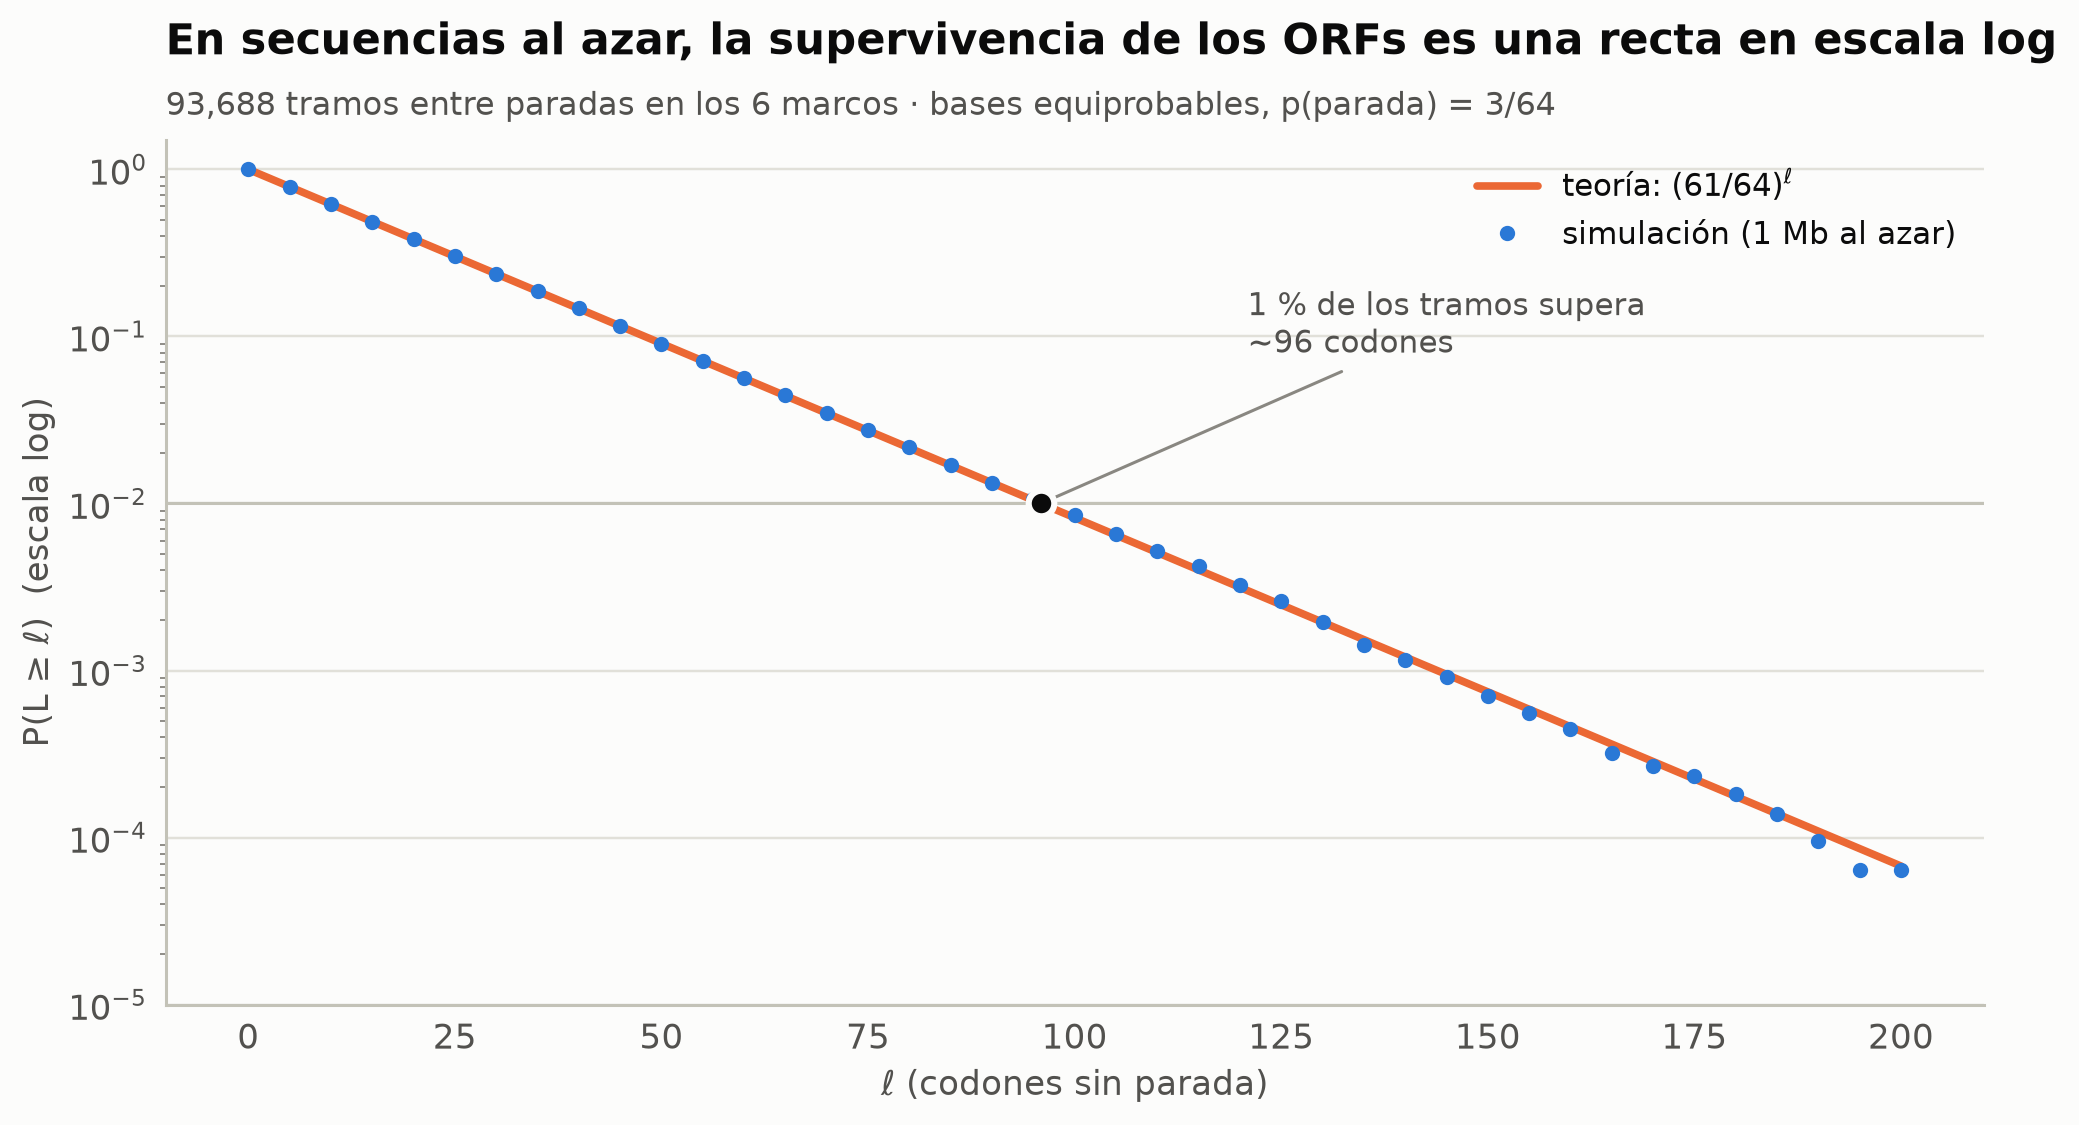

Longitud media simulada = 20.3 codones  (teoría: 20.3)


In [7]:
def stop_to_stop_lengths(seq: str, stops=("TAA", "TAG", "TGA")) -> np.ndarray:
    """Longitudes (en codones) de los tramos entre paradas consecutivas, en los 6 marcos."""
    stop_ids = [codon_id(c) for c in stops]
    rc = seq.translate(COMPLEMENT)[::-1]
    out = []
    for s in (seq, rc):
        for f in range(3):
            pos = np.flatnonzero(np.isin(codon_ids(s[f:]), stop_ids))
            out.append(np.diff(pos) - 1)
    return np.concatenate(out)

def survival(lengths: np.ndarray, grid: np.ndarray) -> np.ndarray:
    srt = np.sort(lengths)
    return 1 - np.searchsorted(srt, grid, side="left") / len(srt)

rng = np.random.default_rng(42)
random_seq = "".join(rng.choice(list("ACGT"), 1_000_000))
lens_random = stop_to_stop_lengths(random_seq)
grid = np.arange(0, 201)
p_stop = 3 / 64

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(grid, (1 - p_stop) ** grid, color=ec.ORANGE, lw=2.5, label="teoría: (61/64)$^\\ell$")
ax.semilogy(grid, survival(lens_random, grid), "o", color=ec.BLUE, ms=4, markevery=5,
            label="simulación (1 Mb al azar)")
ax.axhline(0.01, color=ec.BASELINE, lw=1)
ell_1pct = np.log(0.01) / np.log(1 - p_stop)
ax.scatter([ell_1pct], [0.01], s=70, color=ec.INK, zorder=4, edgecolor=ec.SURFACE, linewidth=2)
ax.annotate(f"1 % de los tramos supera\n~{ell_1pct:.0f} codones", xy=(ell_1pct, 0.01), xytext=(ell_1pct + 25, 0.08),
            fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ax.set_xlabel("ℓ (codones sin parada)")
ax.set_ylabel("P(L ≥ ℓ)  (escala log)")
ax.set_ylim(1e-5, 1.5)
ax.legend(loc="upper right")
ec.title(ax, "En secuencias al azar, la supervivencia de los ORFs es una recta en escala log",
         f"{len(lens_random):,} tramos entre paradas en los 6 marcos · bases equiprobables, p(parada) = 3/64")
plt.show()
print(f"Longitud media simulada = {lens_random.mean():.1f} codones  (teoría: {(1 - p_stop) / p_stop:.1f})")

> 🔎 **Qué observamos.** Los puntos (simulación) caen exactamente sobre la recta (teoría). Sólo 1 de cada 100 tramos
> aleatorios supera unos 96 codones, y prácticamente ninguno llega a 200. Un ORF de 300 codones sería, por azar, un
> evento de uno en un millón.

✅ **Compruebe su comprensión.** Si un genoma usara **sólo dos** codones de parada (en lugar de tres), ¿la recta sería
más empinada o más plana? ¿Qué pasaría con la longitud media de los ORFs al azar?

---

## 5. 🧪 Un genoma real: *Mycoplasma genitalium*

*Mycoplasma genitalium* es una bacteria parásita del tracto urogenital humano con uno de los genomas más pequeños
conocidos para un organismo capaz de crecer en cultivo: unas 580 000 bases y alrededor de 500 genes. Fue el
segundo genoma bacteriano secuenciado (Fraser *et al.*, 1995) y es el modelo clásico del "genoma mínimo".

Descargamos la secuencia de referencia `NC_000908.2` del NCBI (con copia de respaldo en el repositorio del curso):

In [8]:
Entrez.email = "su.correo@ejemplo.com"     # ← escriba aquí su correo
ACCESSION = "NC_000908.2"
BACKUP_URL = f"https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/data/{ACCESSION}.gb"
gb_file = f"{ACCESSION}.gb"

if not os.path.exists(gb_file):
    try:
        with Entrez.efetch(db="nuccore", id=ACCESSION, rettype="gbwithparts", retmode="text") as handle:
            open(gb_file, "w").write(handle.read())
        print("Descargado del NCBI ✔")
    except Exception as err:
        print("NCBI no respondió (", err, ") → usando la copia del curso")
        urllib.request.urlretrieve(BACKUP_URL, gb_file)

record = SeqIO.read(gb_file, "genbank")
genome = str(record.seq).upper()
L = len(genome)

cds_feats = [f for f in record.features if f.type == "CDS" and "pseudo" not in f.qualifiers]
annot = pd.DataFrame([{
    "start": int(f.location.start), "end": int(f.location.end), "strand": f.location.strand,
    "locus_tag": f.qualifiers.get("locus_tag", [""])[0], "gene": f.qualifiers.get("gene", [""])[0],
    "product": f.qualifiers.get("product", [""])[0],
    "transl_table": int(f.qualifiers.get("transl_table", ["11"])[0]),
    "codons": len(f.location) // 3 - 1,
} for f in cds_feats])

gc = (genome.count("G") + genome.count("C")) / L
print(f"{record.description}\nLongitud: {L:,} pb · GC = {gc:.1%} · CDS anotadas (no pseudogenes): {len(annot)}")
print("Código genético declarado en la anotación:", annot["transl_table"].unique())
annot.head()

Descargado del NCBI ✔
Mycoplasmoides genitalium G37, complete sequence
Longitud: 580,076 pb · GC = 31.7% · CDS anotadas (no pseudogenes): 504
Código genético declarado en la anotación: [4]


,start,end,strand,locus_tag,gene,product,transl_table,codons
0,685,1828,1,MG_RS00005,dnaN,DNA polymerase III subunit beta,4,380
1,1827,2760,1,MG_RS00010,,J domain-containing protein,4,310
2,2844,4797,1,MG_RS00015,gyrB,DNA topoisomerase (ATP-hydrolyzing) subunit B,4,650
3,4811,7322,1,MG_RS00020,gyrA,DNA topoisomerase (ATP-hydrolyzing) subunit A,4,836
4,7293,8547,1,MG_RS00025,serS,serine--tRNA ligase,4,417


### Un detalle que cambia todo: el código genético 4

La anotación dice `transl_table = 4`. En los micoplasmas el codón `TGA` **no** es de parada: codifica **triptófano**
(Yamao *et al.*, 1985). Es una de las pocas excepciones al código "universal".

Comparemos las dos tablas en Biopython:

In [9]:
t11, t4 = CodonTable.unambiguous_dna_by_id[11], CodonTable.unambiguous_dna_by_id[4]
print("Tabla 11 (bacterias estándar) → paradas:", t11.stop_codons)
print("Tabla 4  (Mycoplasma)        → paradas:", t4.stop_codons, "| TGA =", t4.forward_table["TGA"])

Tabla 11 (bacterias estándar) → paradas: ['TAA', 'TAG', 'TGA']
Tabla 4  (Mycoplasma)        → paradas: ['TAA', 'TAG'] | TGA = W


🤔 **Antes de ejecutar, prediga:** si traducimos los genes de *M. genitalium* con la tabla estándar (11), ¿qué
fracción de las proteínas saldrá completa? ¿Qué les pasará a las demás?

In [10]:
rows = []
for f in cds_feats:
    nt = f.extract(record.seq)
    full = len(f.qualifiers["translation"][0])
    p4 = len(nt.translate(table=4, to_stop=True))
    p11 = len(nt.translate(table=11, to_stop=True))
    codons = [str(nt[i:i + 3]) for i in range(0, len(nt) - 3, 3)]
    rows.append({"locus_tag": f.qualifiers["locus_tag"][0], "product": f.qualifiers.get("product", [""])[0],
                 "aa_annotated": full, "aa_table4": p4, "aa_table11": p11,
                 "internal_TGA": codons.count("TGA")})
trans = pd.DataFrame(rows)
trans["frac11"] = trans["aa_table11"] / trans["aa_annotated"]
print(f"Proteínas completas con la tabla 4 : {(trans.aa_table4 == trans.aa_annotated).mean():.1%}")
print(f"Proteínas completas con la tabla 11: {(trans.aa_table11 == trans.aa_annotated).mean():.1%}")
print(f"Genes con al menos un TGA interno  : {(trans.internal_TGA > 0).mean():.1%}")

Proteínas completas con la tabla 4 : 100.0%
Proteínas completas con la tabla 11: 28.8%
Genes con al menos un TGA interno  : 71.2%


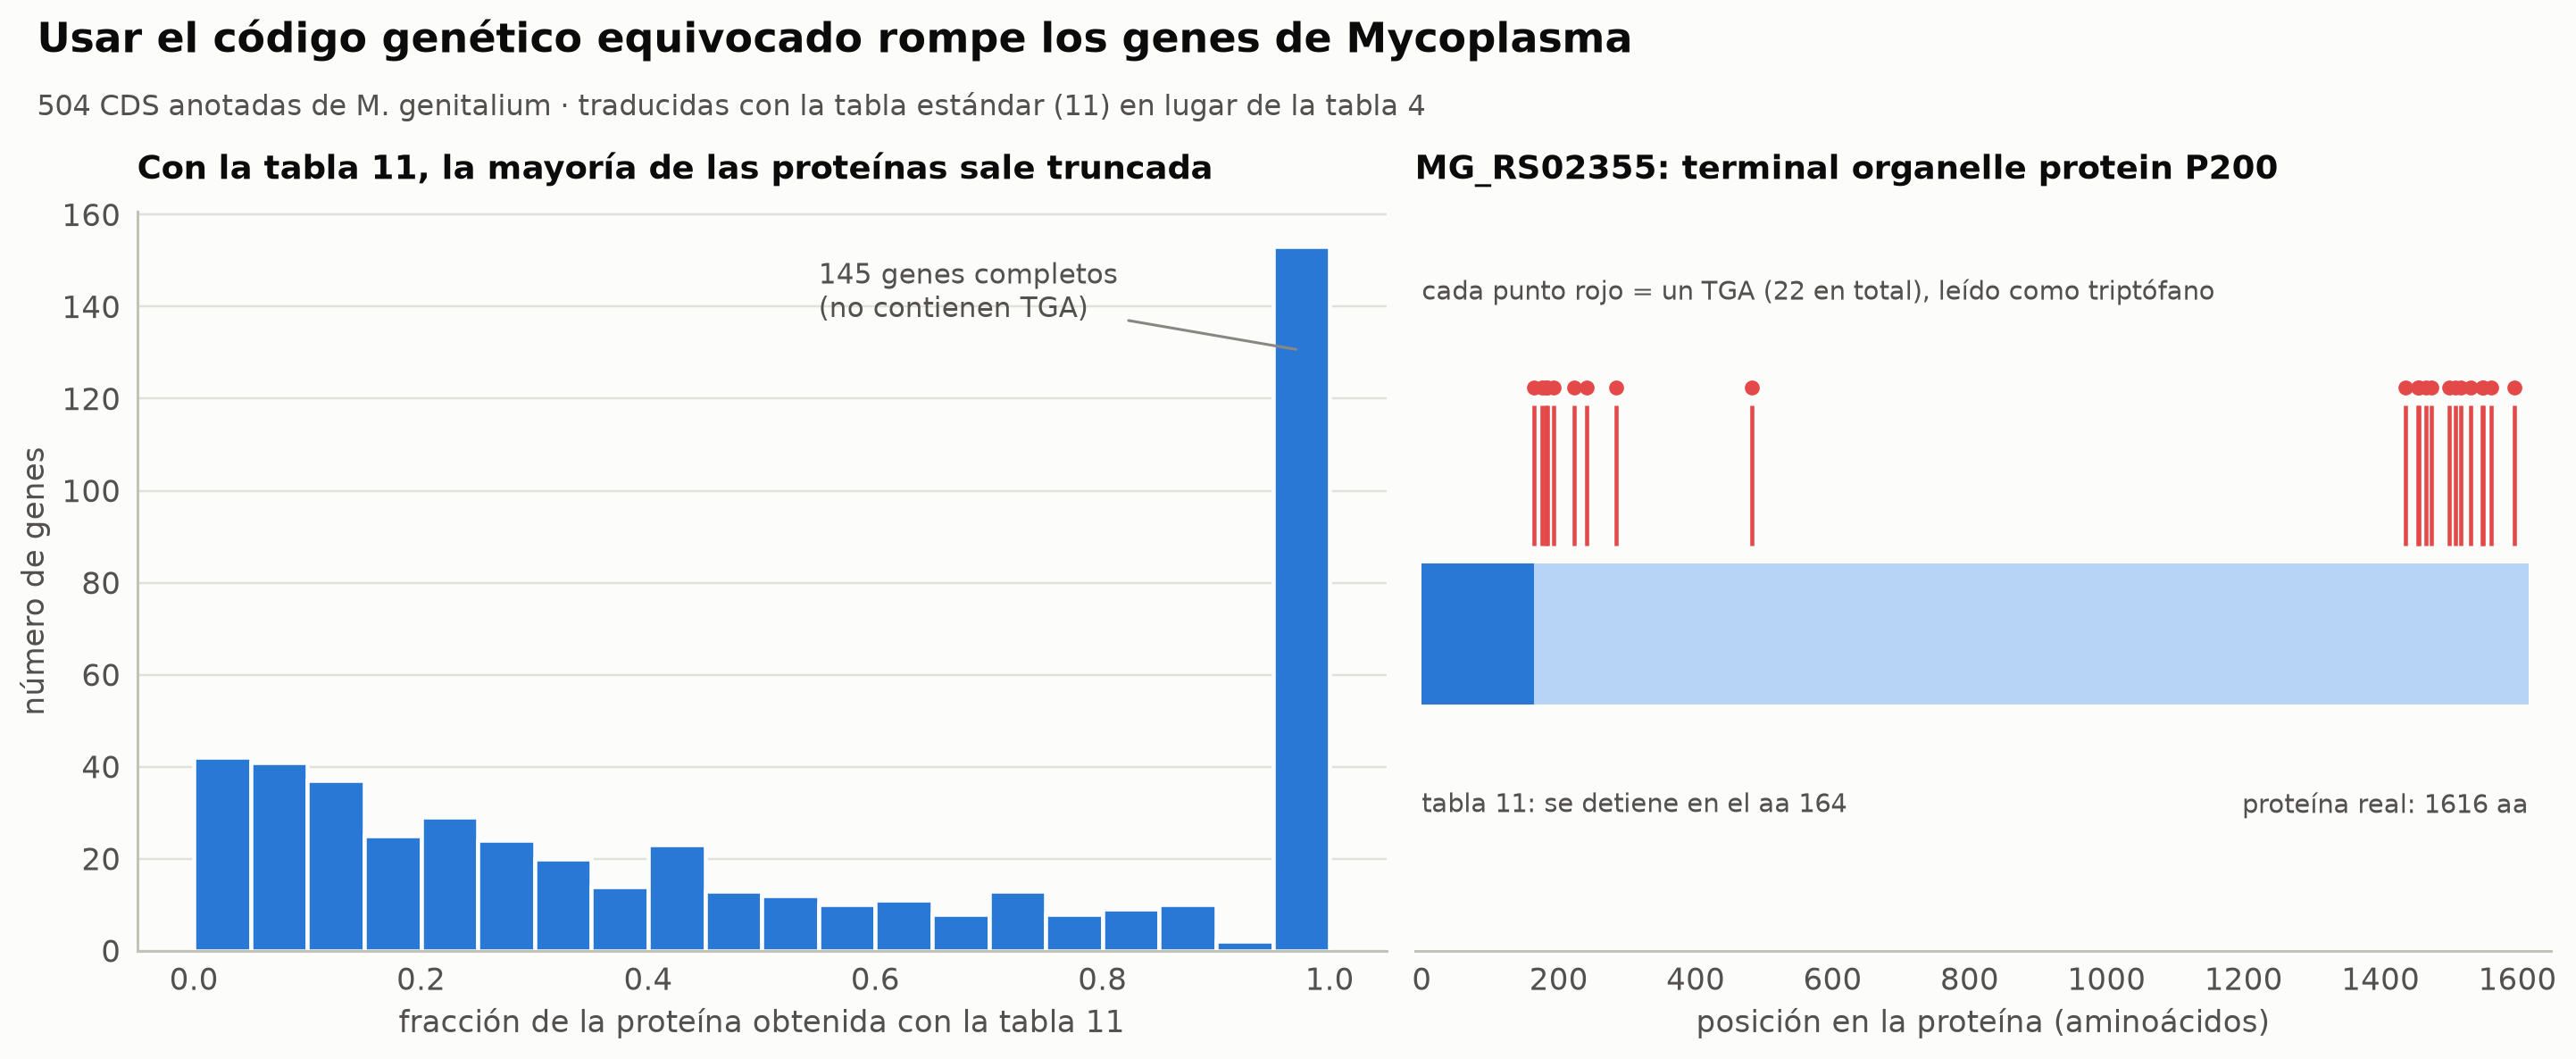

In [11]:
ex = trans.sort_values("internal_TGA", ascending=False).iloc[0]
ex_feat = next(f for f in cds_feats if f.qualifiers["locus_tag"][0] == ex["locus_tag"])
ex_nt = str(ex_feat.extract(record.seq))
tga_pos = [i // 3 for i in range(0, len(ex_nt) - 3, 3) if ex_nt[i:i + 3] == "TGA"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), width_ratios=[1.1, 1])
bins = np.linspace(0, 1, 21)
ax1.hist(trans["frac11"], bins=bins, color=ec.BLUE, edgecolor=ec.SURFACE, linewidth=1.5)
ax1.set_xlabel("fracción de la proteína obtenida con la tabla 11")
ax1.set_ylabel("número de genes")
n_full = (trans["frac11"] >= 0.999).sum()
ax1.annotate(f"{n_full} genes completos\n(no contienen TGA)", xy=(0.975, n_full * 0.9), xytext=(0.55, n_full * 0.95),
             fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ax1.set_title("Con la tabla 11, la mayoría de las proteínas sale truncada", fontsize=12)

n_aa = ex["aa_annotated"]
ax2.add_patch(plt.Rectangle((0, -0.2), n_aa, 0.4, color=ec.SEQ_BLUE[1], lw=0))
ax2.add_patch(plt.Rectangle((0, -0.2), ex["aa_table11"], 0.4, color=ec.BLUE, lw=0))
ax2.vlines(tga_pos, 0.25, 0.65, color=ec.RED, lw=1.5)
ax2.scatter(tga_pos, np.full(len(tga_pos), 0.7), s=30, color=ec.RED, zorder=3)
ax2.text(0, -0.45, f"tabla 11: se detiene en el aa {ex['aa_table11']}", fontsize=9.5, color=ec.INK_2, va="top")
ax2.text(n_aa, -0.45, f"proteína real: {n_aa} aa", fontsize=9.5, color=ec.INK_2, va="top", ha="right")
ax2.text(0, 0.95, f"cada punto rojo = un TGA ({len(tga_pos)} en total), leído como triptófano", fontsize=9.5,
         color=ec.INK_2)
ax2.set_xlim(-10, n_aa * 1.02); ax2.set_ylim(-0.9, 1.2); ax2.set_yticks([]); ax2.grid(False)
ax2.spines["left"].set_visible(False)
ax2.set_xlabel("posición en la proteína (aminoácidos)")
ax2.set_title(f"{ex['locus_tag']}: {ex['product'][:40]}", fontsize=12)
ec.fig_title(fig, "Usar el código genético equivocado rompe los genes de Mycoplasma",
             f"{len(trans)} CDS anotadas de M. genitalium · traducidas con la tabla estándar (11) en lugar de la tabla 4")
plt.show()

> 🔎 **Qué observamos.** Con la tabla 4 **todas** las proteínas coinciden con la anotación; con la tabla 11 sólo
> menos de un tercio sale completa. El resto se "corta" en el primer `TGA`, que para *Mycoplasma* es
> simplemente un triptófano más. Un anotador automático que ignore este detalle predeciría cientos de genes
> fragmentados. **Lección práctica:** antes de anotar un genoma, averigüe qué código genético usa.

---

## 6. 🧪 Señal contra ruido: ORFs reales contra un genoma barajado

¿Cómo sabemos que los ORFs largos de *M. genitalium* no son casualidad? Construimos un **control negativo**:
**barajamos** las letras del genoma. El genoma barajado tiene exactamente la misma composición (mismo % de A, C, G y
T) pero ha perdido toda la información biológica, como un libro al que se le desordenan todas las letras: conserva
cuántas "e" tiene, pero ya no hay palabras. Si el genoma real tiene muchos más ORFs largos que el barajado, esos
ORFs son **señal biológica**.

Además, calculamos la predicción teórica con la **composición real** del genoma y los **dos** codones de parada de la
tabla 4 (`TAA`, `TAG`).

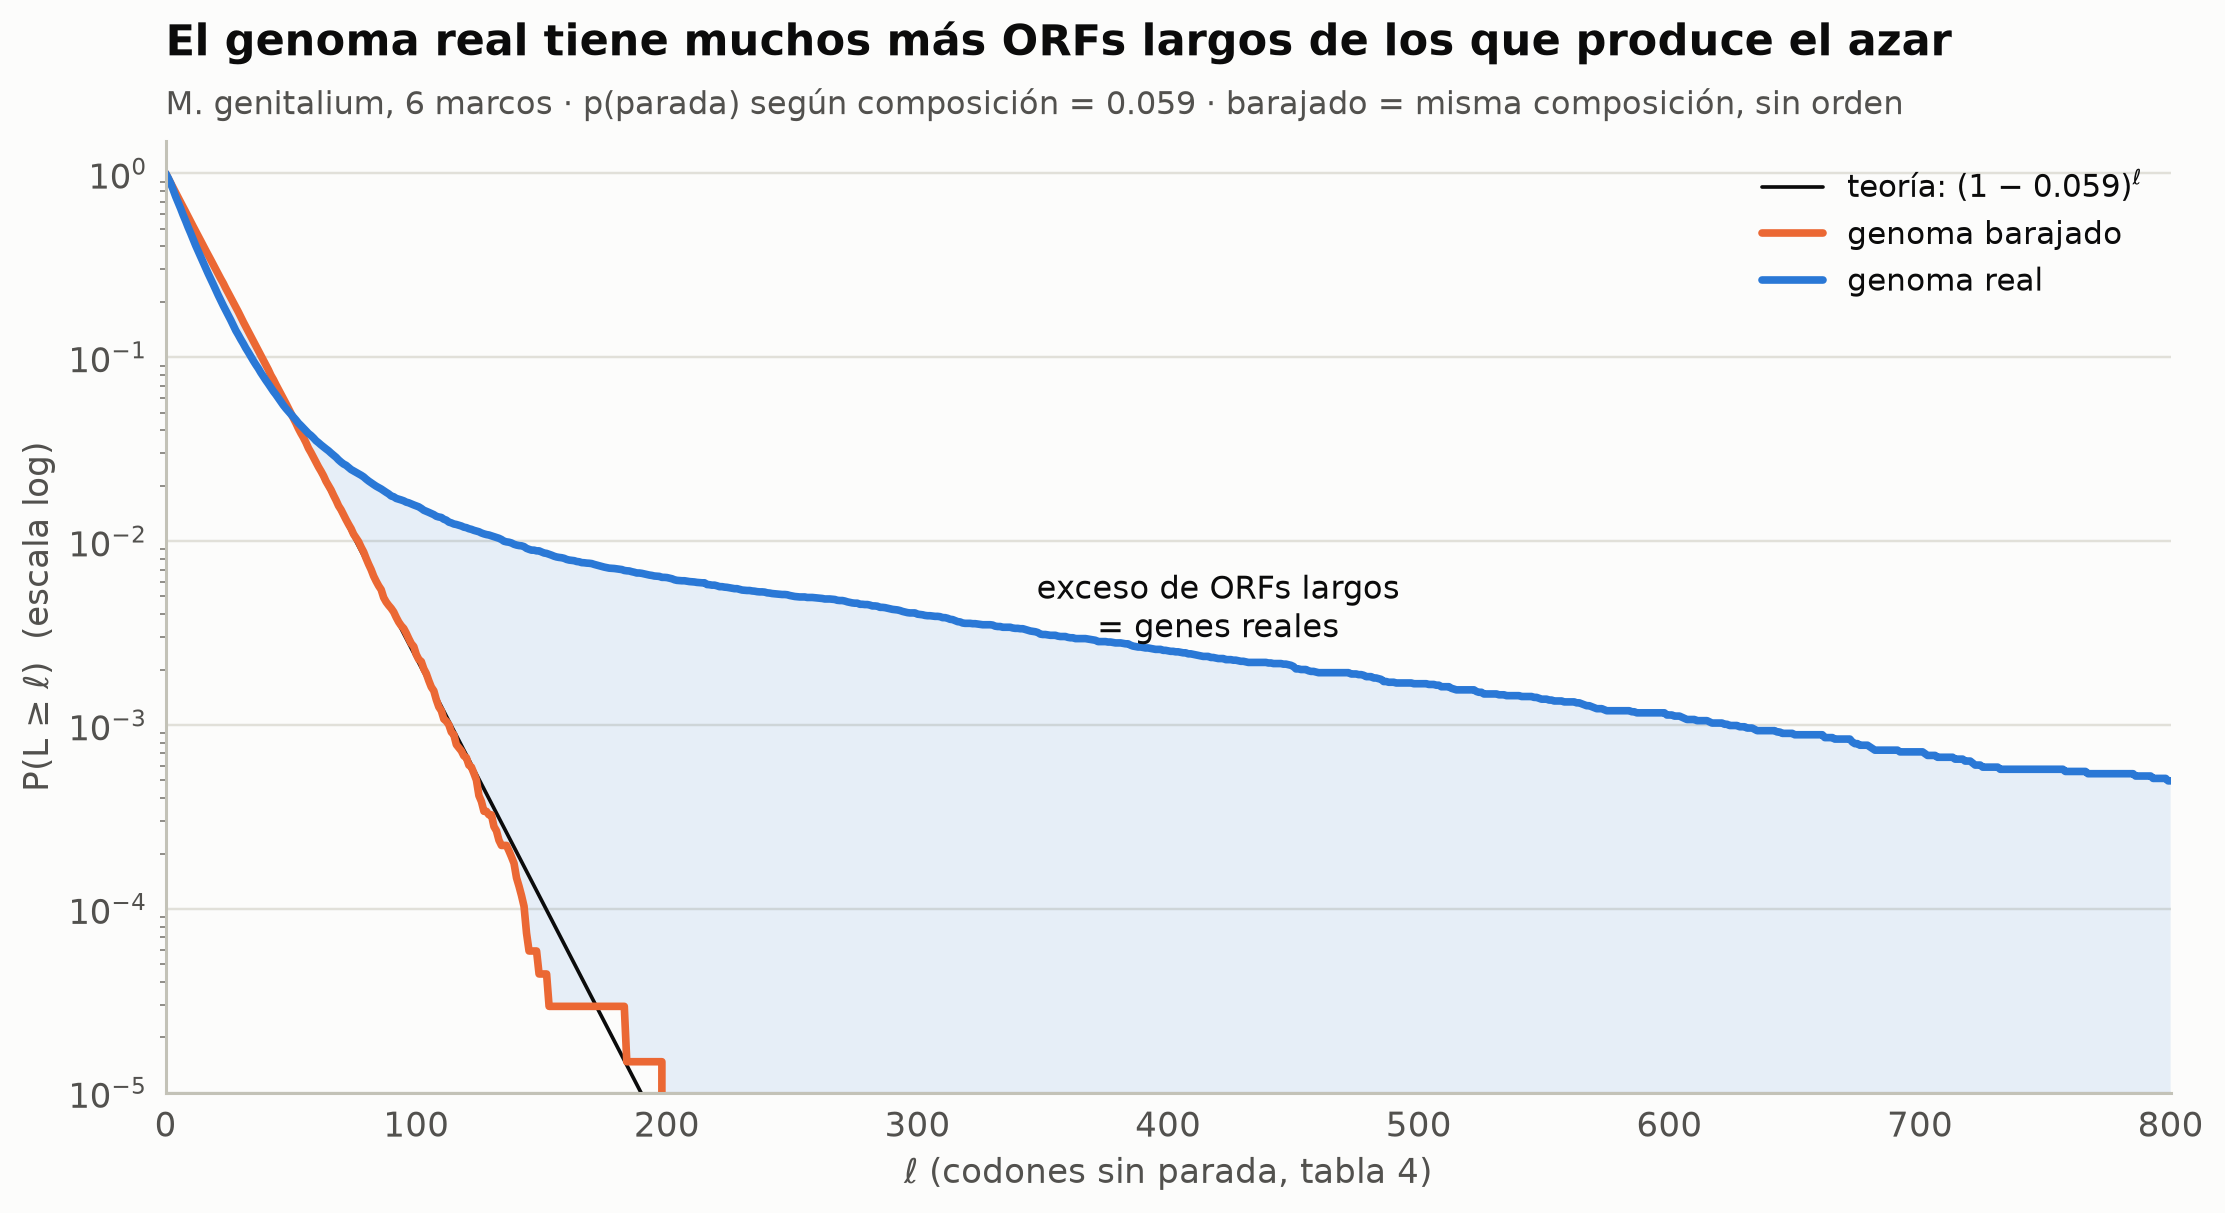

p(parada) con la composición real = 0.0589  → longitud media al azar ≈ 16.0 codones


In [12]:
STOPS_4 = ("TAA", "TAG")
freq = {b: genome.count(b) / L for b in "ACGT"}
p_stop_4 = sum(freq[c[0]] * freq[c[1]] * freq[c[2]] for c in STOPS_4)

rng = np.random.default_rng(2024)
shuffled = "".join(rng.permutation(np.array(list(genome))))

lens_real = stop_to_stop_lengths(genome, STOPS_4)
lens_shuf = stop_to_stop_lengths(shuffled, STOPS_4)
grid = np.arange(0, 801)

fig, ax = plt.subplots(figsize=(10, 5.4))
ax.semilogy(grid, (1 - p_stop_4) ** grid, color=ec.INK, lw=1.2, label=f"teoría: (1 − {p_stop_4:.3f})$^\\ell$")
ax.semilogy(grid, survival(lens_shuf, grid), color=ec.ORANGE, lw=2.5, label="genoma barajado")
ax.semilogy(grid, survival(lens_real, grid), color=ec.BLUE, lw=2.5, label="genoma real")
ax.fill_between(grid, survival(lens_shuf, grid) + 1e-9, survival(lens_real, grid), color=ec.BLUE, alpha=0.1, lw=0)
ax.text(420, 3e-3, "exceso de ORFs largos\n= genes reales", fontsize=10.5, color=ec.INK, ha="center")
ax.set_ylim(1e-5, 1.5); ax.set_xlim(0, 800)
ax.set_xlabel("ℓ (codones sin parada, tabla 4)")
ax.set_ylabel("P(L ≥ ℓ)  (escala log)")
ax.legend(loc="upper right")
ec.title(ax, "El genoma real tiene muchos más ORFs largos de los que produce el azar",
         f"M. genitalium, 6 marcos · p(parada) según composición = {p_stop_4:.3f} · barajado = misma composición, sin orden")
plt.show()
print(f"p(parada) con la composición real = {p_stop_4:.4f}  → longitud media al azar ≈ {(1 - p_stop_4) / p_stop_4:.1f} codones")

> 🔎 **Qué observamos.** Para longitudes cortas, las tres curvas coinciden: la mayoría de los tramos del genoma real
> también son "ruido". Pero para longitudes mayores, el genoma barajado se desploma (siguiendo la recta teórica)
> mientras que el real se separa ya desde unos 50–60 codones y mantiene una "cola pesada" hasta cientos de codones:
> ahí viven los genes.

### ¿Qué umbral mínimo elegimos?

Ahora usamos el buscador completo (con codones de inicio `ATG`, `GTG` y `TTG`, frecuentes en bacterias). Para cada
umbral $\ell_{\min}$ contamos los ORFs en el genoma real y en el barajado. El cociente estima qué fracción de nuestras
predicciones serían falsas (**tasa de falsos descubrimientos**, FDR):

$$
\widehat{\mathrm{FDR}}(\ell_{\min}) \;\approx\; \frac{N_{\text{barajado}}(\ell_{\min})}{N_{\text{real}}(\ell_{\min})}
$$

| Símbolo | Significado |
|---|---|
| $\ell_{\min}$ | longitud mínima exigida a un ORF (en codones) |
| $N_{\text{real}}$ | ORFs con al menos $\ell_{\min}$ codones en el genoma real (genes + ruido) |
| $N_{\text{barajado}}$ | lo mismo en el genoma barajado (sólo ruido): estima cuánto ruido hay en $N_{\text{real}}$ |

Pase el cursor sobre la figura interactiva para leer los valores exactos:

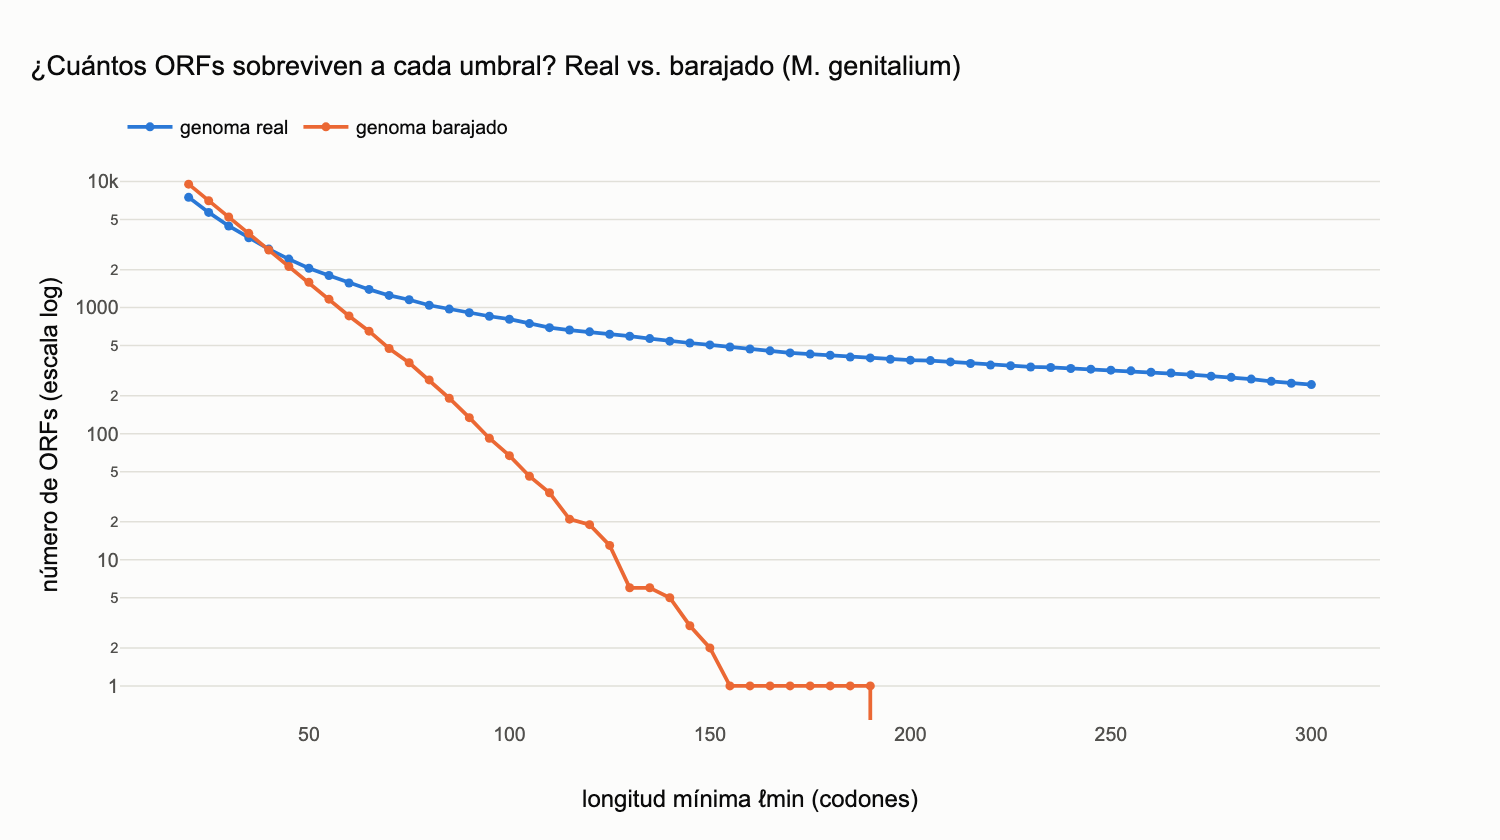

,umbral (codones),genoma real,genoma barajado,FDR estimada
2,30,4442,5226,117.6%
6,50,2050,1590,77.6%
11,75,1155,365,31.6%
16,100,809,67,8.3%
26,150,506,2,0.4%


In [13]:
STARTS_BACT = ("ATG", "GTG", "TTG")
orfs_all_real = find_orfs(genome, min_codons=0, starts=STARTS_BACT, stops=STOPS_4)
orfs_all_shuf = find_orfs(shuffled, min_codons=0, starts=STARTS_BACT, stops=STOPS_4)

thresholds = np.arange(20, 301, 5)
n_real = np.array([(orfs_all_real.codons >= t).sum() for t in thresholds])
n_shuf = np.array([(orfs_all_shuf.codons >= t).sum() for t in thresholds])
fdr = n_shuf / np.maximum(n_real, 1)
thr_df = pd.DataFrame({"umbral (codones)": thresholds, "genoma real": n_real, "genoma barajado": n_shuf,
                       "FDR estimada": fdr})

fig = go.Figure()
for col, color in [("genoma real", ec.BLUE), ("genoma barajado", ec.ORANGE)]:
    fig.add_trace(go.Scatter(x=thr_df["umbral (codones)"], y=thr_df[col], name=col, mode="lines+markers",
                             line=dict(color=color, width=2.5), marker=dict(size=6),
                             customdata=np.c_[thr_df["FDR estimada"]],
                             hovertemplate="ℓmin = %{x} codones<br>" + col + ": %{y:,} ORFs"
                                           "<br>FDR estimada: %{customdata[0]:.1%}<extra></extra>"))
fig.update_layout(title="¿Cuántos ORFs sobreviven a cada umbral? Real vs. barajado (M. genitalium)",
                  xaxis_title="longitud mínima ℓmin (codones)", yaxis_title="número de ORFs (escala log)",
                  yaxis_type="log", height=460, hovermode="x unified",
                  legend=dict(orientation="h", y=1.08, x=0))
fig.show()
thr_df[thr_df["umbral (codones)"].isin([30, 50, 75, 100, 150])].style.format({"FDR estimada": "{:.1%}"})

> 🔎 **Qué observamos.** Con umbrales bajos (30 codones) el genoma barajado produce **tantos o más** ORFs que el real:
> casi todo es ruido. Con 100 codones, el barajado aporta menos del 10 % de lo que vemos en el real. Por eso muchos
> buscadores clásicos usan umbrales de 80–100 codones en bacterias. El precio: los genes **realmente cortos** (menos
> de 100 aminoácidos) se pierden. No existe un umbral perfecto, sólo un **compromiso** entre falsos positivos y
> falsos negativos.

---

## 7. 🧪 Evaluación del predictor: sensibilidad, precisión y ORFs sombra

Tenemos una "respuesta correcta": las CDS anotadas en el GenBank. Diremos que un ORF predicho **acierta** si termina
en el **mismo codón de parada** (y la misma hebra) que un gen anotado. Usamos el extremo 3' porque el codón de parada
es inequívoco, mientras que el inicio real puede ser un `ATG` más adentro del que eligió nuestro algoritmo.

Con eso contamos:

* **VP** (verdaderos positivos): ORFs predichos que coinciden con un gen anotado.
* **FP** (falsos positivos): ORFs predichos que no corresponden a ningún gen.
* **FN** (falsos negativos): genes anotados que el predictor no encontró.

$$
\text{Sensibilidad} = \frac{VP}{VP + FN}
\qquad\qquad
\text{Precisión} = \frac{VP}{VP + FP}
$$

| Medida | Pregunta que responde |
|---|---|
| **Sensibilidad** (*recall*) | De todos los genes reales, ¿qué fracción encontré? |
| **Precisión** | De todo lo que predije, ¿qué fracción es realmente un gen? |

Piense en una red de pesca: la sensibilidad es qué fracción de los peces del lago atrapó; la precisión, qué fracción
de lo que sacó en la red son peces (y no botas viejas).

In [14]:
def three_prime(df):
    """Clave de cada gen/ORF: coordenada de su extremo 3' y hebra."""
    return set(zip(np.where(df.strand == 1, df.end, df.start), df.strand))

annot_keys = three_prime(annot)

def evaluate(pred: pd.DataFrame) -> dict:
    keys = three_prime(pred)
    tp = len(keys & annot_keys)
    return {"predichos": len(pred), "VP": tp, "FP": len(keys) - tp, "FN": len(annot_keys) - tp,
            "sensibilidad": tp / len(annot_keys), "precisión": tp / max(len(keys), 1)}

pred_100 = find_orfs(genome, min_codons=100, starts=STARTS_BACT, stops=STOPS_4)
pd.Series(evaluate(pred_100)).to_frame("ORFs ≥ 100 codones, tabla 4")

,"ORFs ≥ 100 codones, tabla 4"
predichos,809.000000
VP,473.000000
FP,336.000000
FN,31.000000
sensibilidad,0.938492
precisión,0.584672


La sensibilidad es alta, pero la **precisión** es decepcionante: unas cuatro de cada diez predicciones no son genes.
¿De dónde salen tantos falsos positivos? Miremos una región concreta del genoma en los seis marcos:

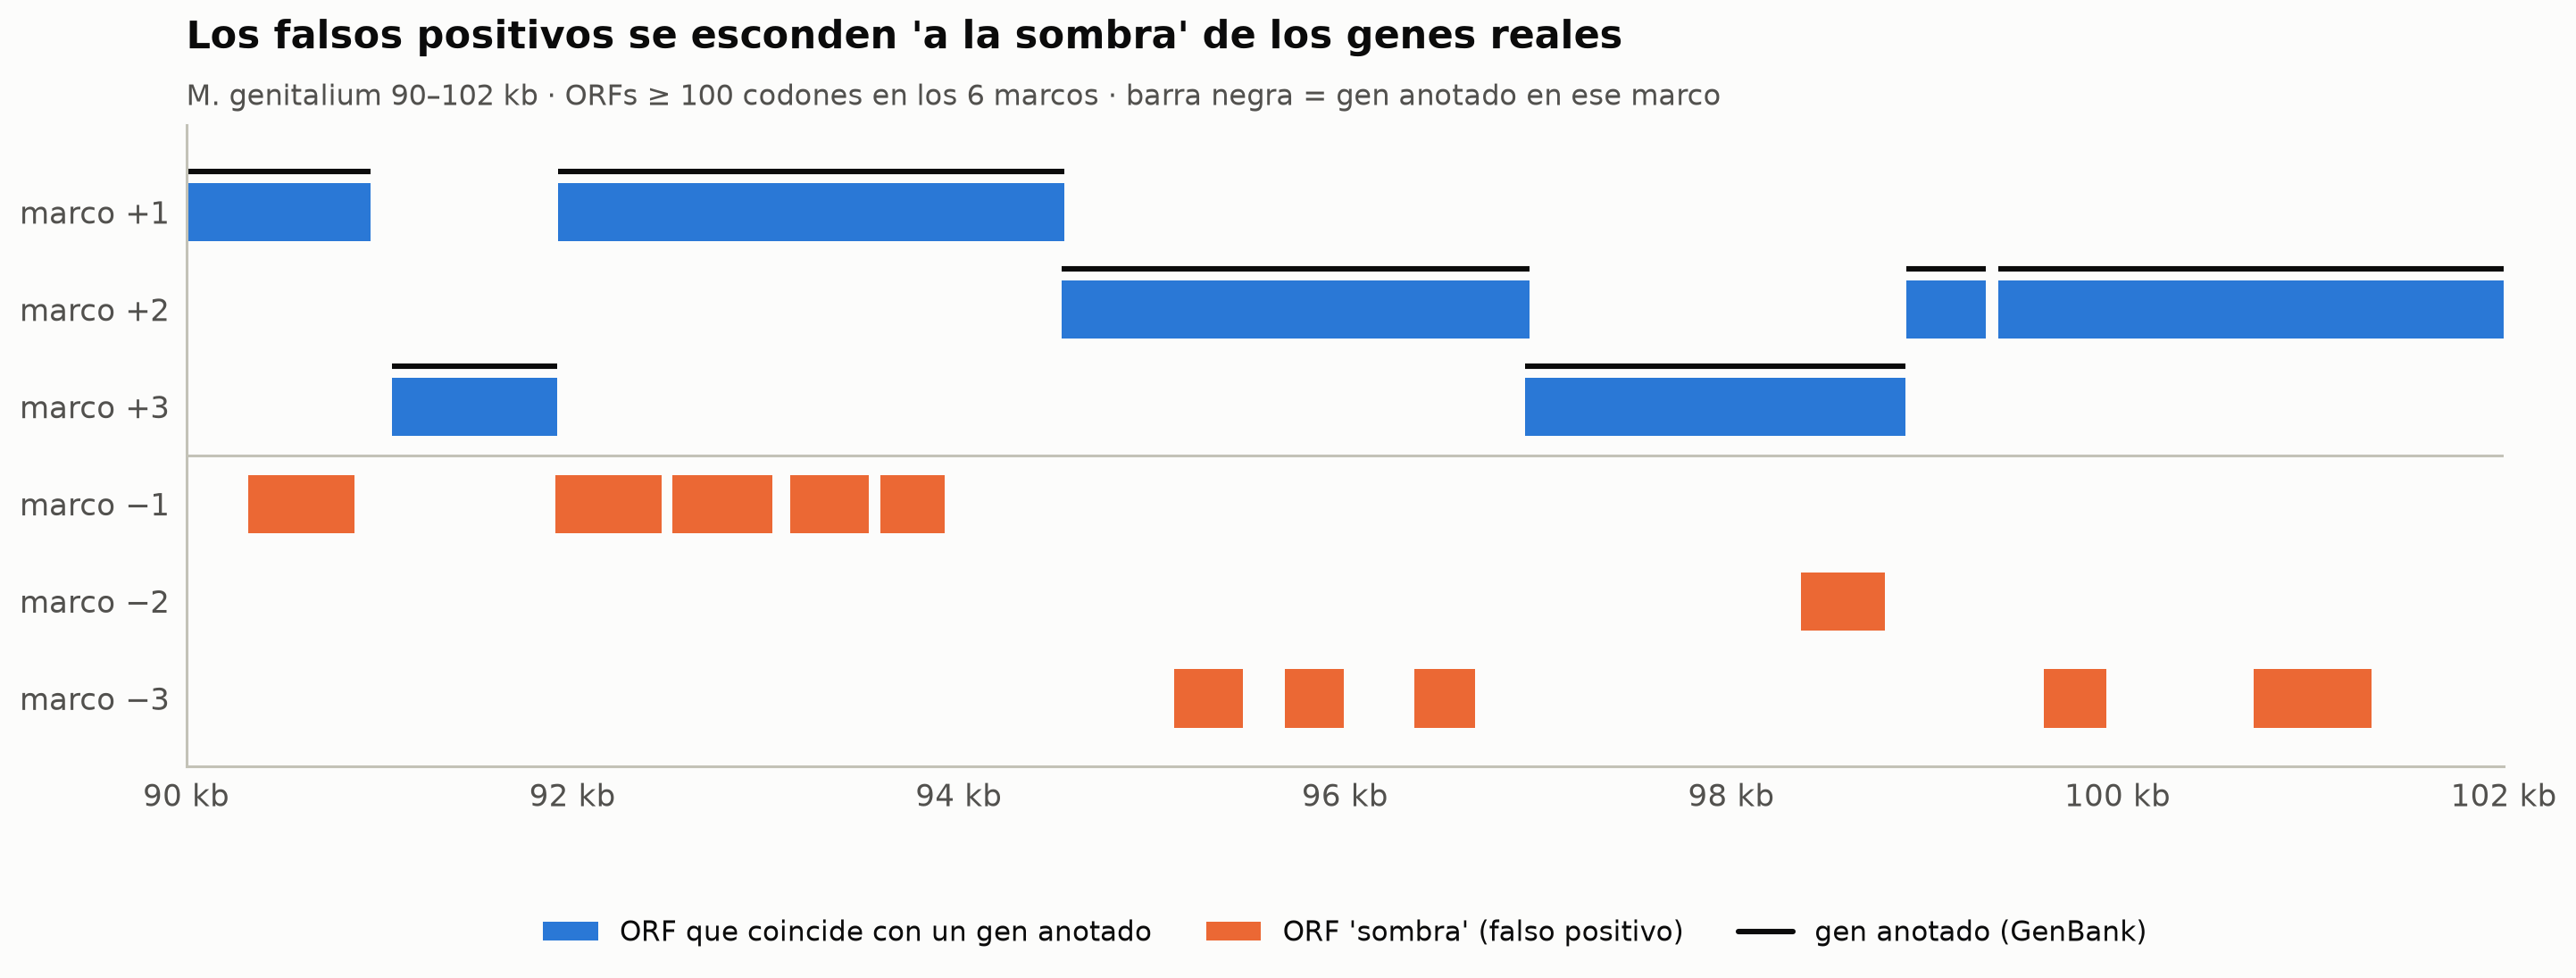

De 336 falsos positivos en todo el genoma: 289 (86%) se solapan > 50 % con un gen real en otro marco o hebra, y 29 caen dentro de pseudogenes.


In [15]:
def lane_of(row):
    """Carril en el gráfico: marcos +1..+3 arriba, −1..−3 abajo."""
    return row["frame"] - 1 if row["strand"] == 1 else 3 + row["frame"] - 1

def frame_of_gene(start, end, strand):
    return (start % 3) + 1 if strand == 1 else ((L - end) % 3) + 1

annot["frame"] = [frame_of_gene(s, e, st) for s, e, st in zip(annot.start, annot.end, annot.strand)]
# Pseudogenes: restos de genes inactivados (no cuentan como CDS "reales")
pseudo = pd.DataFrame([{"start": int(f.location.start), "end": int(f.location.end)}
                       for f in record.features if f.type == "CDS" and "pseudo" in f.qualifiers])

def overlaps_any(s, e, df, frac=0.5):
    ov = np.minimum(e, df.end.to_numpy()) - np.maximum(s, df.start.to_numpy())
    return bool((ov > frac * (e - s)).any())

fp = pred_100[[(e if st == 1 else b, st) not in annot_keys
               for b, e, st in zip(pred_100.start, pred_100.end, pred_100.strand)]]
fp_shadow = np.array([overlaps_any(s, e, annot) for s, e in zip(fp.start, fp.end)])
fp_pseudo = np.array([overlaps_any(s, e, pseudo) for s, e in zip(fp.start, fp.end)])

# Elegimos automáticamente la ventana de 12 kb con más ORFs sombra (solapados con genes reales)
sh_starts = fp.start[fp_shadow].to_numpy()
best = max(range(0, L - 12_000, 2_000), key=lambda x0: ((sh_starts >= x0) & (sh_starts < x0 + 12_000)).sum())
region = (best, best + 12_000)
lane_names = ["+1", "+2", "+3", "−1", "−2", "−3"]

fig, ax = plt.subplots(figsize=(13, 4.8))
sub = pred_100[(pred_100.end > region[0]) & (pred_100.start < region[1])]
for _, r in sub.iterrows():
    hit = (r.end if r.strand == 1 else r.start, r.strand) in annot_keys
    y = -lane_of(r)
    ax.add_patch(plt.Rectangle((r.start, y - 0.3), r.end - r.start, 0.6, color=ec.BLUE if hit else ec.ORANGE, lw=0))
for _, r in annot[(annot.end > region[0]) & (annot.start < region[1])].iterrows():
    y = -lane_of(r)
    ax.plot([r.start, r.end], [y + 0.42, y + 0.42], color=ec.INK, lw=2, solid_capstyle="butt")
pseudo_here = pseudo[(pseudo.end > region[0]) & (pseudo.start < region[1])]
for _, r in pseudo_here.iterrows():
    ax.plot([r.start, r.end], [0.75, 0.75], color=ec.MUTED, lw=2, ls=(0, (2, 2)))
ax.set_yticks([-i for i in range(6)], [f"marco {n}" for n in lane_names])
ax.axhline(-2.5, color=ec.BASELINE, lw=1)
ax.set_xlim(*region); ax.set_ylim(-5.7, 0.9); ax.grid(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb"))
ax.add_patch(plt.Rectangle((0, 0), 0, 0, color=ec.BLUE, label="ORF que coincide con un gen anotado"))
ax.add_patch(plt.Rectangle((0, 0), 0, 0, color=ec.ORANGE, label="ORF 'sombra' (falso positivo)"))
ax.plot([], [], color=ec.INK, lw=2, label="gen anotado (GenBank)")
if len(pseudo_here):
    ax.plot([], [], color=ec.MUTED, lw=2, ls=(0, (2, 2)), label="pseudogén (arriba)")
ax.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.32))
ec.title(ax, "Los falsos positivos se esconden 'a la sombra' de los genes reales",
         f"M. genitalium {region[0]/1000:.0f}–{region[1]/1000:.0f} kb · ORFs ≥ 100 codones en los 6 marcos · barra negra = gen anotado en ese marco")
plt.show()
print(f"De {len(fp)} falsos positivos en todo el genoma: {fp_shadow.sum()} ({fp_shadow.mean():.0%}) se solapan > 50 % "
      f"con un gen real en otro marco o hebra, y {fp_pseudo.sum()} caen dentro de pseudogenes.")

> 🔎 **Qué observamos.** La gran mayoría de los ORFs naranja están **encima de un gen real**, pero en otro marco o en
> la hebra opuesta (el recuento de arriba lo cuantifica para todo el genoma). Son **ORFs sombra**: dentro de un gen,
> la secuencia está "optimizada" para no tener paradas en el marco correcto, y como efecto colateral los otros marcos
> también tienen pocas paradas. Es como la sombra de un edificio: tiene su misma forma, pero no es el edificio.
> Unos pocos falsos positivos caen, además, dentro de **pseudogenes**: restos de genes que perdieron su función y que
> la anotación no cuenta como CDS.

### Un filtro sencillo: quedarse con el ORF más largo

Dos genes rara vez se solapan mucho en bacterias. Regla: ordenamos los ORFs de más largo a más corto y **descartamos
cualquier ORF que se solape más de un 50 % con otro ORF más largo ya aceptado**.

In [16]:
def remove_shadows(orfs: pd.DataFrame, max_overlap: float = 0.5) -> pd.DataFrame:
    """Descarta ORFs que se solapan > max_overlap (fracción de su longitud) con un ORF más largo ya aceptado."""
    order = orfs.assign(length=orfs.end - orfs.start).sort_values("length", ascending=False)
    kept_s, kept_e, keep = np.array([], dtype=int), np.array([], dtype=int), []
    for idx, s, e in zip(order.index, order.start, order.end):
        overlap = np.minimum(e, kept_e) - np.maximum(s, kept_s)
        if len(overlap) == 0 or overlap.max() <= max_overlap * (e - s):
            keep.append(idx)
            kept_s, kept_e = np.append(kept_s, s), np.append(kept_e, e)
    return orfs.loc[sorted(keep)]

pred_100_f = remove_shadows(pred_100)
pd.DataFrame({"sin filtro": evaluate(pred_100), "con filtro de sombras": evaluate(pred_100_f)}).T.style.format(
    {"sensibilidad": "{:.1%}", "precisión": "{:.1%}"})

,predichos,VP,FP,FN,sensibilidad,precisión
sin filtro,809.000000,473.000000,336.000000,31.000000,93.8%,58.5%
con filtro de sombras,502.000000,466.000000,36.000000,38.000000,92.5%,92.8%


¿Cómo cambian ambas medidas con el umbral? 🤔 **Antes de ejecutar, prediga:** al subir $\ell_{\min}$, ¿qué le pasa a
la sensibilidad y qué a la precisión?

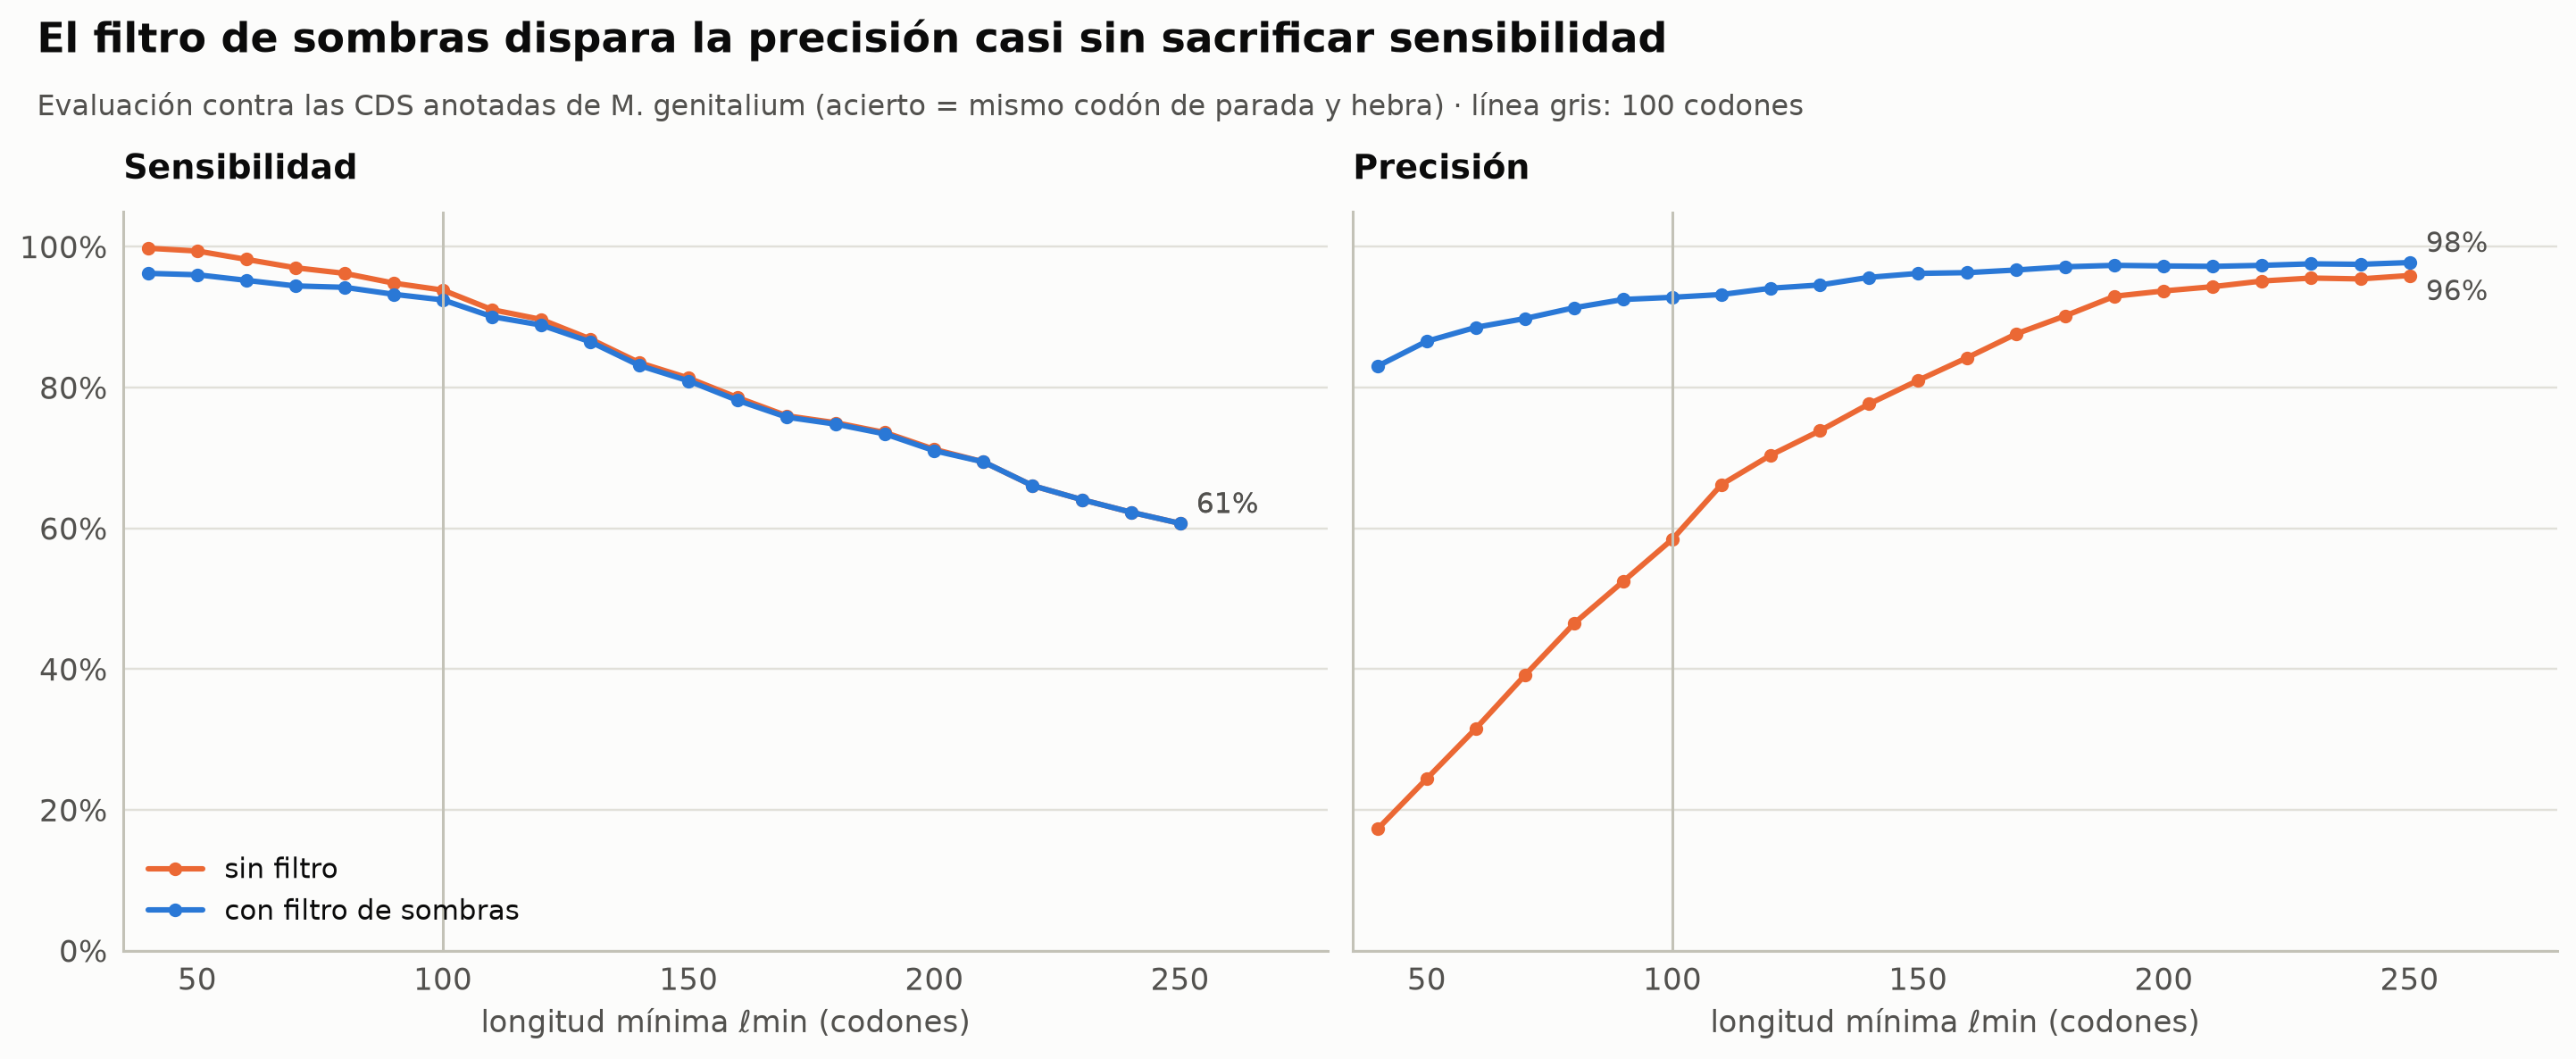

In [17]:
ths = np.arange(40, 251, 10)
res = []
for t in ths:
    p = orfs_all_real[orfs_all_real.codons >= t]
    for name, pred in [("sin filtro", p), ("con filtro de sombras", remove_shadows(p))]:
        res.append({"umbral": t, "método": name, **evaluate(pred)})
res = pd.DataFrame(res)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, metric in zip(axes, ["sensibilidad", "precisión"]):
    for name, color in [("sin filtro", ec.ORANGE), ("con filtro de sombras", ec.BLUE)]:
        d = res[res["método"] == name]
        ax.plot(d["umbral"], d[metric], color=color, marker="o", ms=4, label=name)
        y_end = d[metric].iloc[-1]
        other = res[(res["método"] != name) & (res["umbral"] == ths[-1])][metric].iloc[0]
        nudge = 0 if abs(y_end - other) > 0.04 else (0.025 if y_end >= other else -0.025)
        ec.label_end(ax, d["umbral"].iloc[-1], y_end + nudge, f"{y_end:.0%}")
    ax.axvline(100, color=ec.BASELINE, lw=1)
    ax.set_title(metric.capitalize(), fontsize=12.5)
    ax.set_xlabel("longitud mínima ℓmin (codones)")
    ax.set_xlim(35, 280)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower left")
ec.fig_title(fig, "El filtro de sombras dispara la precisión casi sin sacrificar sensibilidad",
             "Evaluación contra las CDS anotadas de M. genitalium (acierto = mismo codón de parada y hebra) · línea gris: 100 codones")
plt.show()

> 🔎 **Qué observamos.** Al subir el umbral la **sensibilidad cae** (perdemos genes cortos) y la **precisión sube**
> (desaparece el ruido). El filtro de sombras mejora la precisión de forma espectacular a casi cualquier umbral: con
> 100 codones, este buscador de ~40 líneas encuentra más del 90 % de los genes con una precisión similar. Programas
> profesionales como **Prodigal** o **GLIMMER** añaden modelos estadísticos del uso de codones, de la señal de
> Shine-Dalgarno y del contexto, y superan el 95–99 %.

---

## 8. 🧭 Un navegador genómico interactivo

Explore el genoma completo. Use la **barra inferior** o arrastre sobre el gráfico para acercarse; pase el cursor sobre
cada gen u ORF para ver sus coordenadas, longitud y función. Los genes anotados que el predictor **no** encontró
aparecen en magenta: ¿qué tienen en común? (Pista: mire su longitud.)

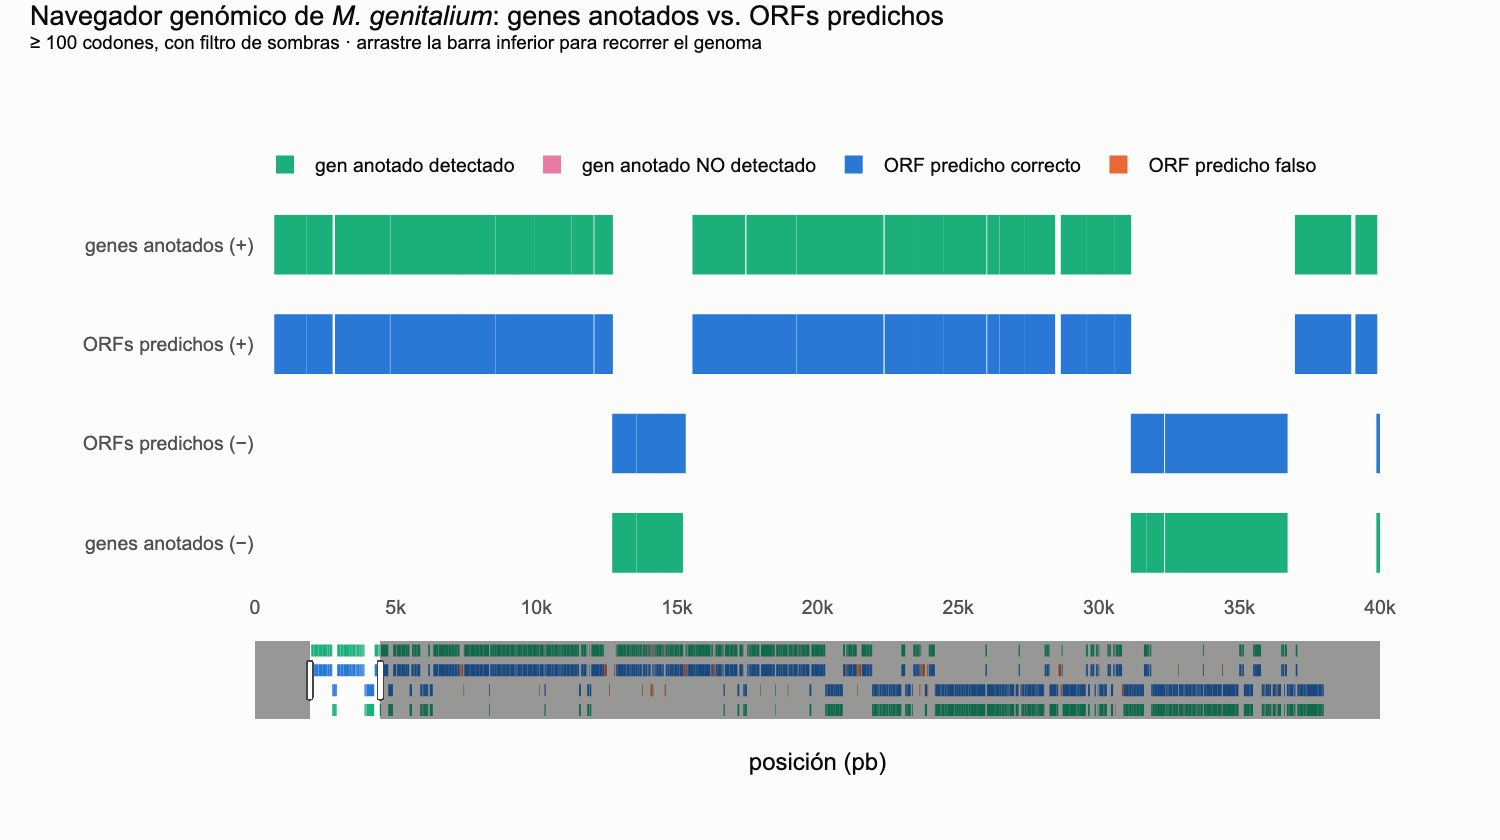

Genes no detectados: 38 · mediana de su longitud: 82 codones (genes detectados: 305)


In [18]:
pred_keys = three_prime(pred_100_f)
annot["found"] = [(e if s == 1 else b, s) in pred_keys for b, e, s in zip(annot.start, annot.end, annot.strand)]
pred_plot = pred_100_f.copy()
pred_plot["hit"] = [(e if s == 1 else b, s) in annot_keys for b, e, s in zip(pred_plot.start, pred_plot.end, pred_plot.strand)]
prod_by_key = {(e if s == 1 else b, s): (lt, pr) for b, e, s, lt, pr in
               zip(annot.start, annot.end, annot.strand, annot.locus_tag, annot["product"])}

lanes = {"genes anotados (+)": 3, "ORFs predichos (+)": 2, "ORFs predichos (−)": 1, "genes anotados (−)": 0}
fig = go.Figure()

def add_track(df, lane_y, name, color, hover):
    fig.add_trace(go.Bar(x=df.end - df.start, base=df.start, y=[lane_y] * len(df), orientation="h",
                         marker=dict(color=color, line=dict(width=0)), width=0.6, name=name,
                         hovertext=hover, hoverinfo="text"))

for strand, lane_a, lane_p in [(1, 3, 2), (-1, 0, 1)]:
    a = annot[annot.strand == strand]
    for found, color, label in [(True, ec.AQUA, "gen anotado detectado"), (False, ec.MAGENTA, "gen anotado NO detectado")]:
        d = a[a.found == found]
        hover = [f"<b>{lt}</b> {g}<br>{pr}<br>{s + 1:,}–{e:,} ({'+' if st == 1 else '−'})<br>{c} codones · marco {fr}"
                 for lt, g, pr, s, e, st, c, fr in zip(d.locus_tag, d.gene, d["product"], d.start, d.end, d.strand,
                                                       d.codons, d.frame)]
        add_track(d, lane_a, label + (" " if strand == 1 else "  "), color, hover)
    p = pred_plot[pred_plot.strand == strand]
    for hit, color, label in [(True, ec.BLUE, "ORF predicho correcto"), (False, ec.ORANGE, "ORF predicho falso")]:
        d = p[p.hit == hit]
        hover = []
        for s, e, st, c, fr in zip(d.start, d.end, d.strand, d.codons, d.frame):
            lt, pr = prod_by_key.get((e if st == 1 else s, st), ("sin gen anotado", ""))
            hover.append(f"<b>ORF</b> {s + 1:,}–{e:,} ({'+' if st == 1 else '−'}) · marco {fr}<br>{c} codones<br>{lt} {pr}")
        add_track(d, lane_p, label + (" " if strand == 1 else "  "), color, hover)

# una sola entrada de leyenda por categoría
seen = set()
for tr in fig.data:
    key = tr.name.strip()
    tr.legendgroup = key; tr.showlegend = key not in seen; tr.name = key; seen.add(key)

fig.update_layout(title=dict(text="Navegador genómico de <i>M. genitalium</i>: genes anotados vs. ORFs predichos"
                             "<br><sup>≥ 100 codones, con filtro de sombras · arrastre la barra inferior para recorrer el genoma</sup>",
                             y=0.97),
                  barmode="overlay", height=520, margin=dict(l=170, t=130), xaxis=dict(range=[0, 40_000], rangeslider=dict(visible=True),
                                                           title="posición (pb)"),
                  yaxis=dict(tickvals=list(lanes.values()), ticktext=list(lanes.keys()), showgrid=False),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()
missed = annot[~annot.found]
print(f"Genes no detectados: {len(missed)} · mediana de su longitud: {missed.codons.median():.0f} codones "
      f"(genes detectados: {annot[annot.found].codons.median():.0f})")

> 🔎 **Qué observamos.** La mayoría de los genes que se nos escapan son **cortos** (por debajo del umbral) o tienen un
> codón de inicio poco común. Detectar genes pequeños sigue siendo uno de los problemas abiertos de la anotación
> genómica: muchas proteínas de menos de 50 aminoácidos se descubrieron apenas en la última década.

---

## ✍️ Ejercicios

**Ejercicio 1 — La composición manda.** Calcule $p(\text{parada})$ y la longitud media esperada de un ORF al azar
para un genoma con 20 %, 50 % y 72 % de GC (tabla 11, $p_G = p_C = \mathrm{GC}/2$). ¿En cuál es más fácil
confundir ruido con genes? ¿Por qué los genomas ricos en GC (como *Streptomyces*) son más difíciles de anotar con
un simple umbral de longitud?

**Ejercicio 2 — El ORF más largo de SARS-CoV-2.** Descargue el genoma de SARS-CoV-2 (`NC_045512.2`, disponible en
`data/` del repositorio) y encuentre sus 5 ORFs más largos con `find_orfs` (tabla estándar). ¿Coinciden con ORF1a,
S y N?

**Ejercicio 3 — Sólo ATG.** Repita la evaluación con ORFs ≥ 100 codones y filtro de sombras, pero usando sólo `ATG`
como codón de inicio. ¿Cuánto cambia la sensibilidad? ¿Por qué?

**Ejercicio 4 — Un genoma circular.** El genoma de *M. genitalium* es **circular**: un gen puede empezar cerca del
final de la secuencia y terminar al principio. Proponga cómo modificar `find_orfs` para detectarlos (pista: concatenar
el genoma consigo mismo) y compruebe si la anotación tiene algún gen que cruce la posición 1.

In [19]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
for gc_ in [0.20, 0.50, 0.72]:
    pb = {"G": gc_ / 2, "C": gc_ / 2, "A": (1 - gc_) / 2, "T": (1 - gc_) / 2}
    p = sum(pb[c[0]] * pb[c[1]] * pb[c[2]] for c in ("TAA", "TAG", "TGA"))
    l99 = np.log(0.01) / np.log(1 - p)
    print(f"GC = {gc_:.0%}: p(parada) = {p:.4f} · longitud media = {(1 - p) / p:5.1f} codones · 1 % supera {l99:4.0f} codones")
print("En genomas ricos en GC las paradas (ricas en A/T) escasean: el azar produce ORFs largos y el umbral debe subir.")

GC = 20%: p(parada) = 0.0960 · longitud media =   9.4 codones · 1 % supera   46 codones
GC = 50%: p(parada) = 0.0469 · longitud media =  20.3 codones · 1 % supera   96 codones
GC = 72%: p(parada) = 0.0169 · longitud media =  58.3 codones · 1 % supera  271 codones
En genomas ricos en GC las paradas (ricas en A/T) escasean: el azar produce ORFs largos y el umbral debe subir.


In [20]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
sars_file = "NC_045512.2.gb"
if not os.path.exists(sars_file):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/data/NC_045512.2.gb", sars_file)
sars = SeqIO.read(sars_file, "genbank")
top = find_orfs(str(sars.seq), min_codons=50).nlargest(5, "codons")
genes_sars = [(int(f.location.start), int(f.location.end), f.qualifiers["gene"][0]) for f in sars.features if f.type == "CDS"]
top["gen anotado con el mismo final"] = [next((g for s, e, g in genes_sars if e == row.end), "—") for row in top.itertuples()]
top

,start,end,strand,frame,codons,gen anotado con el mismo final
0,265,13483,1,2,4405,ORF1ab
19,13767,21555,1,1,2595,ORF1ab
26,21535,25384,1,2,1282,S
43,28273,29533,1,2,419,N
31,25392,26220,1,1,275,ORF3a


In [21]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
pred_atg = remove_shadows(find_orfs(genome, min_codons=100, starts=("ATG",), stops=STOPS_4))
pd.DataFrame({"ATG/GTG/TTG": evaluate(pred_100_f), "sólo ATG": evaluate(pred_atg)}).T
# Los genes que empiezan con GTG/TTG y no tienen un ATG antes de la parada anterior quedan sin detectar.

,predichos,VP,FP,FN,sensibilidad,precisión
ATG/GTG/TTG,502.0,466.0,36.0,38.0,0.924603,0.928287
sólo ATG,485.0,454.0,31.0,50.0,0.900794,0.936082


In [22]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
wrapped = find_orfs(genome + genome[:3000], min_codons=100, starts=STARTS_BACT, stops=STOPS_4)
crossing = wrapped[(wrapped.start < L) & (wrapped.end > L)]
print("ORFs que cruzan el origen de coordenadas:", len(crossing))
print("Genes anotados con localización compuesta (cruzan la posición 1):",
      sum(len(f.location.parts) > 1 for f in cds_feats))

ORFs que cruzan el origen de coordenadas: 1
Genes anotados con localización compuesta (cruzan la posición 1): 0


## 📌 Resumen

* Un gen codificante bacteriano es un tramo continuo desde un codón de inicio hasta el primer codón de parada **del
  mismo marco**; en eucariotas los intrones interrumpen ese tramo.
* Toda secuencia tiene **seis marcos de lectura**; un buscador de ORFs los recorre todos.
* Por azar, la longitud de un tramo sin paradas sigue una **distribución geométrica**: $P(L \ge \ell) = (1-p)^\ell$,
  una recta en escala logarítmica. Los genes reales forman una "cola" muy por encima de esa recta.
* La probabilidad de parada depende de la **composición** del genoma y del **código genético**: *Mycoplasma* lee `TGA`
  como triptófano, y usar la tabla equivocada trunca dos tercios de sus proteínas.
* Evaluamos predictores con **sensibilidad** y **precisión**; los **ORFs sombra** son la principal fuente de falsos
  positivos, y un filtro de solapamiento los elimina casi todos.

**Próxima lección (1.3):** composición de secuencias — *GC skew* y cómo encontrar el origen de replicación de un
genoma bacteriano sólo mirando sus letras.

## 📚 Para profundizar

* Fraser, C. M. *et al.* (1995). The minimal gene complement of *Mycoplasma genitalium*. *Science* 270(5235): 397–403.
* Yamao, F. *et al.* (1985). UGA is read as tryptophan in *Mycoplasma capricolum*. *PNAS* 82(8): 2306–2309.
* Delcher, A. L. *et al.* (1999). Improved microbial gene identification with GLIMMER. *Nucleic Acids Research*
  27(23): 4636–4641.
* Hyatt, D. *et al.* (2010). Prodigal: prokaryotic gene recognition and translation initiation site identification.
  *BMC Bioinformatics* 11: 119.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)